In [1]:
# General
import sys
import os.path as op
from time import time
from collections import OrderedDict as od
from importlib import reload
import warnings
from glob import glob
import itertools
import h5py

# Scientific
import numpy as np
import pandas as pd
pd.options.display.max_rows = 200
pd.options.display.max_columns = 999
import scipy.io as sio

# Stats
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import random
from sklearn.preprocessing import minmax_scale
from sklearn.decomposition import PCA
from scipy.ndimage.filters import gaussian_filter1d

# Plots
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.path as mpath
import matplotlib.patches as patches
from matplotlib.backends.backend_pdf import PdfPages
mpl.rcParams['grid.linewidth'] = 0.1
mpl.rcParams['grid.alpha'] = 0.75
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['axes.grid'] = False
mpl.rcParams['axes.axisbelow'] = True
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.formatter.offset_threshold'] = 2
mpl.rcParams['errorbar.capsize'] = 4
mpl.rcParams['lines.linewidth'] = 0.8
mpl.rcParams['lines.markersize'] = 3
mpl.rcParams['lines.markeredgewidth'] = 0
mpl.rcParams['font.size'] = 6
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['xtick.major.pad'] = 2.5
mpl.rcParams['ytick.major.pad'] = 2.5
mpl.rcParams['xtick.major.size'] = 2.5
mpl.rcParams['ytick.major.size'] = 2.5
mpl.rcParams['axes.labelsize'] = 8
mpl.rcParams['axes.labelpad'] = 6
mpl.rcParams['axes.titlesize'] = 10
mpl.rcParams['figure.titlesize'] = 10
mpl.rcParams['legend.fontsize'] = 6
mpl.rcParams['legend.handletextpad'] = 2.5
mpl.rcParams['legend.borderpad'] = 0
mpl.rcParams['legend.loc'] = 'upper right'
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['figure.figsize'] = (6.45, 2.58)
mpl.rcParams['figure.subplot.wspace'] = 0.25
mpl.rcParams['figure.subplot.hspace'] = 0.25
mpl.rcParams['savefig.format'] = 'pdf'
mpl.rcParams['pdf.fonttype'] = 42
colors = ['296eb4', 'e10600', '00A676', 'B74F6F', 'FF6B35',
          '8c564b', 'e377c2', '7f7f7f', 'bcbd22', '17becf']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler('color', colors)

# Personal
sys.path.append('/home1/john/Goldmine/general')
sys.path.append('/home1/john/Goldmine/time_cells_goldmine')
%load_ext autoreload
%autoreload
# sys.path.append('/home1/dscho/code/general')
# sys.path.append('/home1/dscho/code/projects/manning_replication')
# sys.path.append('/home1/dscho/code/projects')
from helper_funcs import *
import data_io as dio
import array_operations as aop
from eeg_plotting import plot_trace, plot_trace2
import spike_sorting, spike_preproc, events_preproc, events_proc, time_bin_analysis, time_cell_plots, pop_decoding

font = {'tick': 12,
        'label': 14,
        'annot': 12,
        'fig': 16}

# Colors
n = 4
c = 2
colors = [sns.color_palette('Blues', n)[c], 
          sns.color_palette('Reds', n)[c], 
          sns.color_palette('Greens', n)[c],
          sns.color_palette('Purples', n)[c],
          sns.color_palette('Oranges', n)[c],
          sns.color_palette('Greys', n)[c],
          sns.color_palette('YlOrBr', n+3)[c],
          'k']
cmap = sns.palettes.blend_palette((colors[0], 
                                   'w',
                                   colors[1]), 501)

colws = od([('1', 6.55),
            ('2-1/2', 3.15),
            ('2-1/3', 2.1),
            ('2-2/3', 4.2),
            ('3', 2.083),
            ('4', 1.525),
            ('5', 1.19),
            ('6', 0.967),
            (1, 2.05),
            (2, 3.125),
            (3, 6.45),
            ('nat1w', 3.50394),
            ('nat2w', 7.20472),
            ('natl', 9.72441)])

# these two lines import replay_functions from path not on sys.path.append
import runpy
rf = runpy.run_path("/home1/john/Goldmine/john_time_cells/replay_functions.py")

goldmine_concept_sessions = [
    'U567','U571','U576','U581','U582','U583','U584'
]

In /home1/john/anaconda3/envs/workshopJ/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The text.latex.preview rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /home1/john/anaconda3/envs/workshopJ/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The mathtext.fallback_to_cm rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /home1/john/anaconda3/envs/workshopJ/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: Support for setting the 'mathtext.fallback_to_cm' rcParam is deprecated since 3.3 and will be removed two minor releases later; use 'mathtext.fallback : 'cm' instead.
In /home1/john/anaconda3/envs/workshopJ/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle: 
The validate_bool_maybe_none function was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
In /

# Load the data

In [2]:
# Get sessions.

# original
# proj_dir = '/home1/dscho/projects/time_cells'
proj_dir = '/data7/goldmine'

sessions = np.unique([op.basename(f).split('-')[0] 
                      for f in glob(op.join(proj_dir, 'analysis', 'events', '*.pkl'))])
print('{} subjects, {} sessions'.format(len(np.unique([x.split('_')[0] for x in sessions])), len(sessions)))

10 subjects, 12 sessions


In [3]:
n_rois = 4

# Load processed OLS files.
mod_pairs_globstr = op.join(proj_dir, 'analysis', 'unit_to_behav_1000perm', '*Encoding_Retrieval-ols_model_pairs.pkl')
ols_weights_globstr = op.join(proj_dir, 'analysis', 'unit_to_behav_1000perm', '*Encoding_Retrieval-ols_weights.pkl')
# mod_pairs_globstr = op.join(proj_dir, 'analysis', 'unit_to_behav', '*Encoding_Retrieval-ols_model_pairs.pkl')
# ols_weights_globstr = op.join(proj_dir, 'analysis', 'unit_to_behav', '*Encoding_Retrieval-ols_weights.pkl')
time_field_globstr = op.join(proj_dir, 'analysis', 'time_fields', '*Encoding_Retrieval-smooth3*.pkl')
mod_pairs = pd.concat([dio.open_pickle(f) for f in glob(mod_pairs_globstr)]).reset_index(drop=True)
ols_weights = pd.concat([dio.open_pickle(f) for f in glob(ols_weights_globstr)]).reset_index(drop=True)
time_fields = pd.concat([dio.open_pickle(f)['time_fields'] for f in glob(time_field_globstr)]).reset_index(drop=True)

# Drop rows.
drop_red = ['full-time,gameState:time', 'full-place,gameState:place',
            'fullMax-time,gameState:time', 'fullMax-place,gameState:place',
            'full+penalty-time:penalty', 'full+penalty-place:penalty',
            'full+goldDug-time:goldDug', 'full+goldDug-place:goldDug',
            'fullMax+penalty-time:penalty', 'fullMax+penalty-place:penalty',
            'fullMax+goldDug-time:goldDug', 'fullMax+goldDug-place:goldDug']
mod_pairs = mod_pairs.query("(red!={})".format(drop_red)).reset_index(drop=True)

# Add columns.
_map = od({'full-gameState'                : 'gameState',
           'full-time'                     : 'time',
           'full-gameState:time'           : 'gameState:time',
           'full-place'                    : 'place',
           'full-gameState:place'          : 'gameState:place',
           'full-time:place'               : 'time:place',
           'full+penalty-time:penalty'     : 'time:penalty',
           'full+penalty-place:penalty'    : 'place:penalty',
           'full+goldDug-time:goldDug'     : 'time:goldDug',
           'full+goldDug-place:goldDug'    : 'place:goldDug',
            'fullMax-gameState'             : 'max-gameState',
            'fullMax-time'                  : 'max-time',
            'fullMax-gameState:time'        : 'max-gameState:time',
            'fullMax-place'                 : 'max-place',
            'fullMax-gameState:place'       : 'max-gameState:place',
            'fullMax-time:place'            : 'max-time:place',
           # 'fullMax-gameState'             : 'gameState', # to replicate what was there in terms of cell counts comment out these 6 and uncomment 6 above
           # 'fullMax-time'                  : 'time',
           # 'fullMax-gameState:time'        : 'gameState:time',
           # 'fullMax-place'                 : 'place',
           # 'fullMax-gameState:place'       : 'gameState:place',
           # 'fullMax-time:place'            : 'time:place',
           'fullMax+penalty-time:penalty'  : 'time:penalty',
           'fullMax+penalty-place:penalty' : 'place:penalty',
           'fullMax+goldDug-time:goldDug'  : 'time:goldDug',
           'fullMax+goldDug-place:goldDug' : 'place:goldDug'})

testvar_cat = pd.CategoricalDtype(['gameState', 'time', 'gameState:time', 'place', 'gameState:place', 'time:place',
                                   'max-gameState', 'max-time', 'max-gameState:time', 'max-place', 'max-gameState:place', 'max-time:place',
#                                    'time:penalty', 'place:penalty', 'time:goldDug', 'place:goldDug',                                  
#                                    'max-time:penalty', 'max-place:penalty', 'max-time:goldDug', 'max-place:goldDug'
                                  ], ordered=True)
mod_pairs.insert(4, 'testvar', mod_pairs['red'].apply(lambda x: _map[x]))
mod_pairs['testvar'] = mod_pairs['testvar'].astype(testvar_cat)
mod_pairs.insert(1, 'subj', mod_pairs['subj_sess_unit'].apply(lambda x: x.split('_')[0]))
roi_map = spike_preproc.roi_mapping(n=n_rois)
mod_pairs.insert(mod_pairs.columns.tolist().index('roi')+1, 'roi_gen', mod_pairs['roi'].apply(lambda x: roi_map.get(x, np.nan)))
mod_pairs.insert(mod_pairs.columns.tolist().index('roi')+2, 'is_hpc', mod_pairs['roi_gen'].apply(lambda x: x == 'HPC'))

all_unit_list = np.unique(mod_pairs.subj_sess_unit)

# Add time field info.
for game_state in ['Encoding', 'Retrieval']:
    _time_fields = (time_fields.query("(field_type=='pos') & (gameState=='{}')".format(game_state))
                               .sort_values('peak_z', ascending=False)
                               .drop_duplicates(['subj_sess_unit'])
                               .reset_index(drop=True))
    cols = ['subj_sess_unit', 'field_peak', 'peak_z', 'field_size', 'field_idx']
    mod_pairs = pd.merge(mod_pairs, _time_fields[cols], how='left', on=['subj_sess_unit'])
    mod_pairs.rename(columns={col: '{}_{}'.format(col, game_state)
                              for col in ['field_peak', 'peak_z', 'field_size', 'field_idx']},
                     inplace=True)

# Get region labels.

# rois_if = od([('HPC', ['AH', 'MH']),
#               ('AMY', ['A']),
#               ('ERCX', ['EC']),
#               ('PHG/FSG', ['PHG', 'FSG']),
#               ('HSG', ['HGa']),
#               ('mOCC', ['mOCC']),
#               ('mPFC', ['OF', 'AC', 'pSMA']),
#               ('Other', ['AI', 'PC', 'PI'])])
for df in (mod_pairs, ols_weights):
    # only want roi (subregion), hem (L or R), and roi_gen (general region from roi_mapping) # JS
    df.drop(columns=[col for col in ['hemroi', 'roi_if', 'roi_gen', 'is_hpc'] if col in df.columns], inplace=True)
    
    # Generate mapping dictionary for roi → roi_gen
    roi_map = spike_preproc.roi_mapping(n=n_rois)

    # Add 'roi_gen' by mapping existing 'roi' values
    df.insert(2, 'roi_gen', df['roi'].map(roi_map).fillna('Unknown'))    
    
    # df.drop(columns=[col for col in ['hemroi', 'hem', 'roi', 'roi_if'] if col in df.columns], inplace=True)    
    # df.insert(1, 'hemroi', df['subj_sess_unit'].apply(lambda x: spike_preproc.roi_lookup(x.split('-')[0], x.split('-')[1])))
    # df.insert(2, 'hem', df['hemroi'].apply(lambda x: x[0]))
    # df.insert(3, 'roi', df['hemroi'].apply(lambda x: x[1:]))
    # df.insert(4, 'roi_if', df['roi'].apply(lambda x: invert_dict(rois_if)[x]))
    
print('mod_pairs: {}'.format(mod_pairs.shape))
print('ols_weights: {}'.format(ols_weights.shape))
print('time_fields: {}'.format(time_fields.shape))

mod_pairs: (5484, 24)
ols_weights: (529206, 10)
time_fields: (444, 8)


In [4]:
# FDR correct across all neurons.
alpha = 0.05
sig_col = 'sig'

mod_pairs['sig01'] = ''
mod_pairs['sig_fdr'] = ''
for testvar in mod_pairs['testvar'].unique():
    pvals = mod_pairs.loc[mod_pairs['testvar']== testvar, 'emp_pval']
    sig_fdr = sm.stats.multipletests(pvals, alpha, method='fdr_tsbky')[0]
    pvals_fdr = sm.stats.multipletests(pvals, alpha, method='fdr_tsbky')[1]
    
    mod_pairs.loc[mod_pairs['testvar']==testvar, 'sig01'] = pvals < 0.01
    mod_pairs.loc[mod_pairs['testvar']==testvar, 'pvals_fdr'] = pvals_fdr
    mod_pairs.loc[mod_pairs['testvar']==testvar, 'sig_fdr'] = sig_fdr
    
sig_cells = od([])
for testvar in mod_pairs['testvar'].unique():
    sig_cells[testvar] = mod_pairs.query("(testvar=='{}') & ({}==True)".format(testvar, sig_col))['subj_sess_unit'].tolist()

In [5]:
# How many neurons for each subject, from each region?
roi_col = 'roi_gen'
neuron_counts = (pd.pivot(mod_pairs.drop_duplicates('subj_sess_unit')
                                   .groupby(['subj', roi_col])
                                   .size()
                                   .reset_index()
                                   .rename(columns={0: 'count'}),
                          index='subj', columns='roi_gen', values='count')
                 .fillna(0)
                 .astype(int))

idx = np.argsort(neuron_counts.sum(axis=1))[::-1]
neuron_counts = neuron_counts.iloc[idx, :]
neuron_counts = neuron_counts.append(neuron_counts.sum(axis=0), ignore_index=True)
neuron_counts.columns.name = None
neuron_counts['Sum'] = neuron_counts.sum(axis=1)

neuron_counts

,HPC,MTL,PFC,TPC,Sum
0,11,61,9,21,102
1,9,37,27,0,73
2,19,19,0,28,66
3,24,25,1,15,65
4,14,3,15,11,43
5,9,16,8,0,33
6,11,6,8,0,25
7,5,19,0,0,24
8,4,9,0,0,13
9,3,9,1,0,13


In [6]:
# What variables have >chance numbers of sig. cells?
testvars = ['gameState', 'time', 'gameState:time',
            'place', 'gameState:place', 'time:place']

count_sig = od([])
count_all = od([])
n_cells = mod_pairs['subj_sess_unit'].unique().size
pvals_unc = od([])
for testvar in testvars:
    n_sig = len(sig_cells[testvar])
    binom_p = stats.binom_test(n_sig,
                               n_cells,
                               p=0.05,
                               alternative='greater')
    count_sig[testvar] = n_sig
    count_all[testvar] = n_cells
    pvals_unc[testvar] = binom_p

# Bonferroni-Holm correct
pvals_corr = sm.stats.multipletests(list(pvals_unc.values()), method='holm')[1]

for iTest, testvar in enumerate(pvals_unc):
    print('{:>19}'.format(testvar),
          '{:>2}/{:>2} {:>5.1%} '.format(count_sig[testvar], count_all[testvar], (1. * count_sig[testvar]) / count_all[testvar]),
          '{:.10f}{:>1}'.format(pvals_unc[testvar], '*' if (pvals_unc[testvar] < alpha) else ''),
          '{:.10f}{:>1}'.format(pvals_corr[iTest], '*' if (pvals_corr[iTest] < alpha) else ''))
    
# ---------------------------------------------------------------
testvars = ['max-gameState', 'max-time', 'max-gameState:time',
            'max-place', 'max-gameState:place', 'max-time:place']

count_sig = od([])
count_all = od([])
n_cells = mod_pairs['subj_sess_unit'].unique().size
pvals_unc = od([])
for testvar in testvars:
    n_sig = len(sig_cells[testvar])
    binom_p = stats.binom_test(n_sig,
                               n_cells,
                               p=0.05,
                               alternative='greater')
    count_sig[testvar] = n_sig
    count_all[testvar] = n_cells
    pvals_unc[testvar] = binom_p

# Bonferroni-Holm correct
pvals_corr = sm.stats.multipletests(list(pvals_unc.values()), method='holm')[1]

print('')
for iTest, testvar in enumerate(pvals_unc):
    print('{:>19}'.format(testvar),
          '{:>2}/{:>2} {:>5.1%} '.format(count_sig[testvar], count_all[testvar], (1. * count_sig[testvar]) / count_all[testvar]),
          '{:.10f}{:>1}'.format(pvals_unc[testvar], '*' if (pvals_unc[testvar] < alpha) else ''),
          '{:.10f}{:>1}'.format(pvals_corr[iTest], '*' if (pvals_corr[iTest] < alpha) else ''))

          gameState 59/457 12.9%  0.0000000000* 0.0000000002*
               time 23/457  5.0%  0.5170858077  0.7023441694 
     gameState:time 64/457 14.0%  0.0000000000* 0.0000000000*
              place 60/457 13.1%  0.0000000000* 0.0000000001*
    gameState:place 25/457  5.5%  0.3511720847  0.7023441694 
         time:place 43/457  9.4%  0.0000676592* 0.0002029775*

      max-gameState 43/457  9.4%  0.0000676592* 0.0002706367*
           max-time 20/457  4.4%  0.7591101636  0.8641566543 
 max-gameState:time 45/457  9.8%  0.0000155170* 0.0000775851*
          max-place 48/457 10.5%  0.0000014330* 0.0000085979*
max-gameState:place 24/457  5.3%  0.4320783271  0.8641566543 
     max-time:place 42/457  9.2%  0.0001363121* 0.0004089364*


# Percent responses to each variable

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


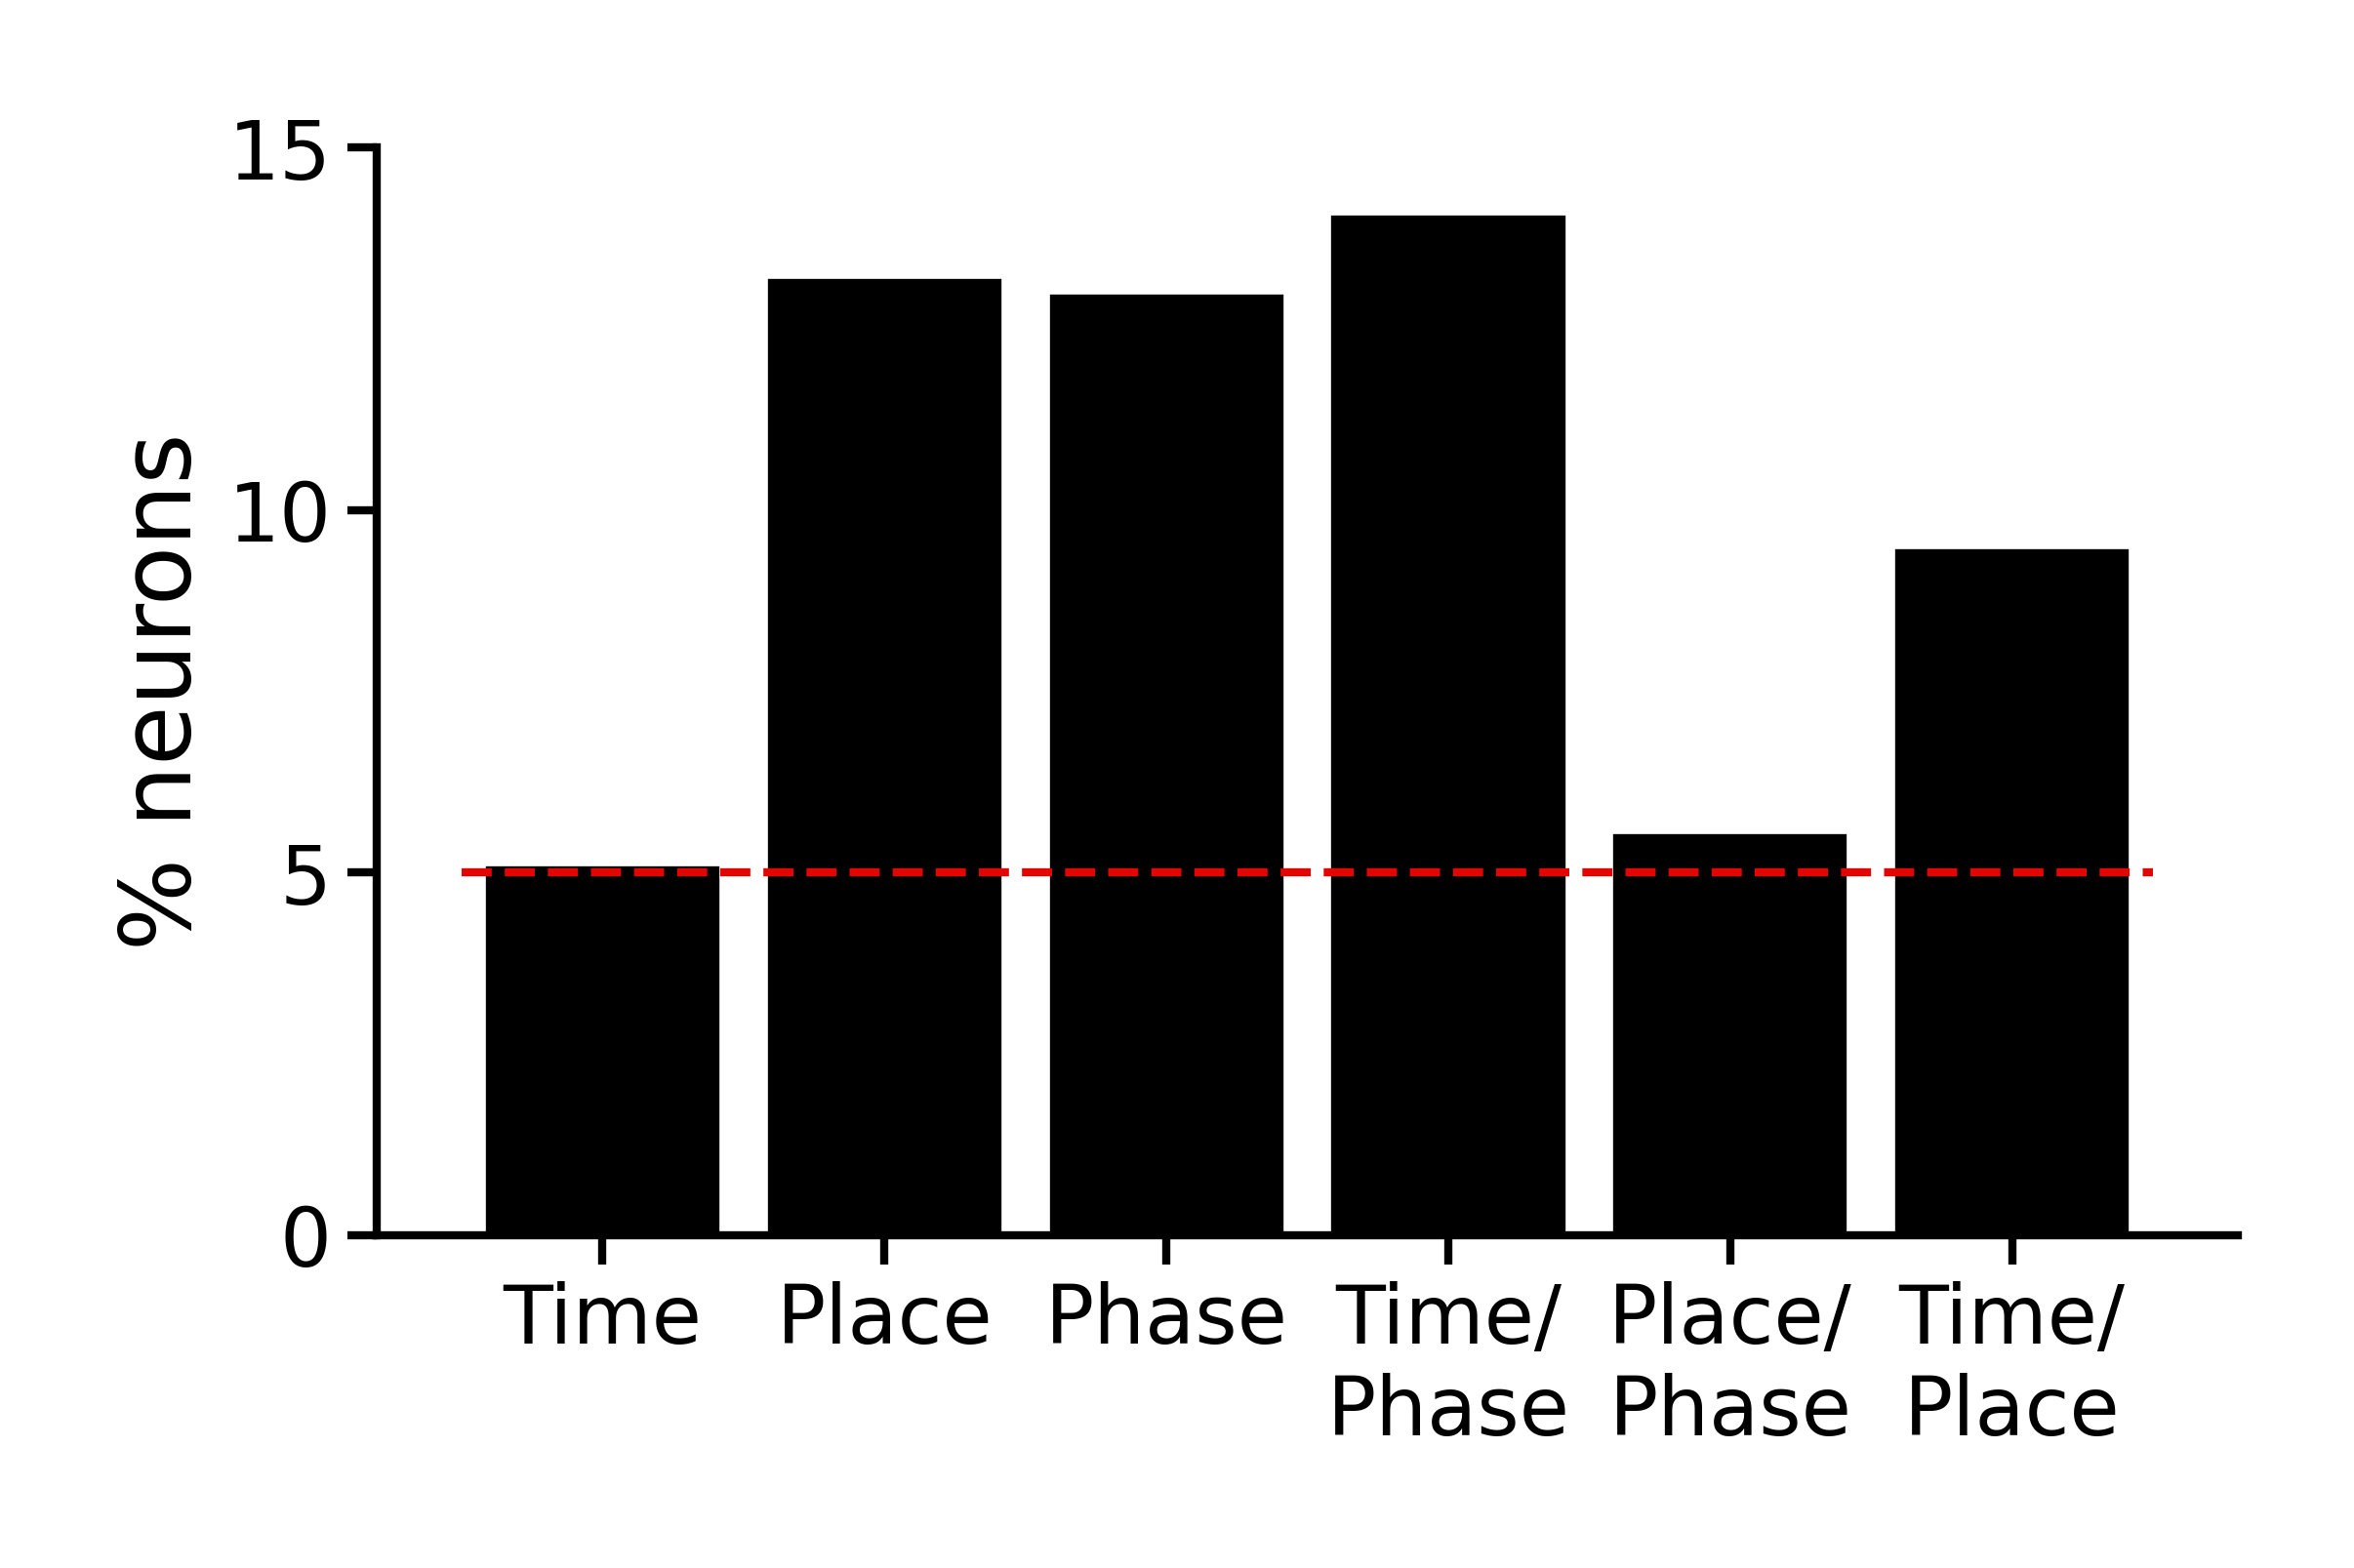

In [7]:
savefig = 0
overwrite = 0
sig_col = 'sig'
full = 'full'
test_vars = ['time', 'place', 'gameState', 'gameState:time', 'gameState:place', 'time:place']
xcats = ['Time', 'Place', 'Phase', 'Time/\nPhase', 'Place/\nPhase', 'Time/\nPlace']
ylim = [0, 15]
yticks = [0, 5, 10, 15]
figsize = (colws[1], colws[1] * 0.6)
font = {'tick': 5, 'label': 6, 'annot': 5}
spine_lw = 0.5
spine_len = 1.8
labelpad = 2

# Graph percent of units that code for each variable of interest.
_df = mod_pairs.query("(full=='{}')".format(full)).copy()
_df['testvar'] = _df['testvar'].astype(pd.CategoricalDtype(test_vars, ordered=True))
_df = _df.groupby(['testvar'], observed=True)['sig'].apply(lambda x: 100 * np.mean(x)).reset_index()

# Make the plot.
plt.close()
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=1200)
ax = sns.barplot(x='testvar', y='sig', color='k', data=_df, ax=ax,
                 saturation=1, linewidth=spine_lw, edgecolor='k')
ax.hlines(5, -0.5, len(test_vars) - 0.5, colors='#e10600', linestyles='dashed', lw=spine_lw)
for axis in ['left', 'bottom']:
    ax.spines[axis].set_linewidth(spine_lw)
ax.tick_params(labelsize=font['tick'], pad=1, length=spine_len, width=spine_lw)
ax.set_xticklabels(xcats, fontsize=font['tick'])
ax.set_ylim(ylim)
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)
ax.set_xlabel('', fontsize=font['label'], labelpad=labelpad)
ax.set_ylabel('% neurons', fontsize=font['label'], labelpad=labelpad-1)

if savefig:
    n_units = np.unique(mod_pairs['subj_sess_unit']).size
    filename = op.join(proj_dir, 'figs', 'plot_navigation2',
                       'pct_sig-time_place_gameState_+interactions-{}units.pdf'.format(n_units))
    if overwrite or not op.exists(filename):
        fig.savefig(filename, format='pdf', bbox_inches='tight')
            
fig.show();

In [23]:
mod_pairs.query("(full=='fullMax')")['testvar'].unique()

['max-gameState', 'max-time', 'max-gameState:time', 'max-place', 'max-gameState:place', 'max-time:place']
Categories (12, object): ['gameState' < 'time' < 'gameState:time' < 'place' ... 'max-gameState:time' < 'max-place' < 'max-gameState:place' < 'max-time:place']

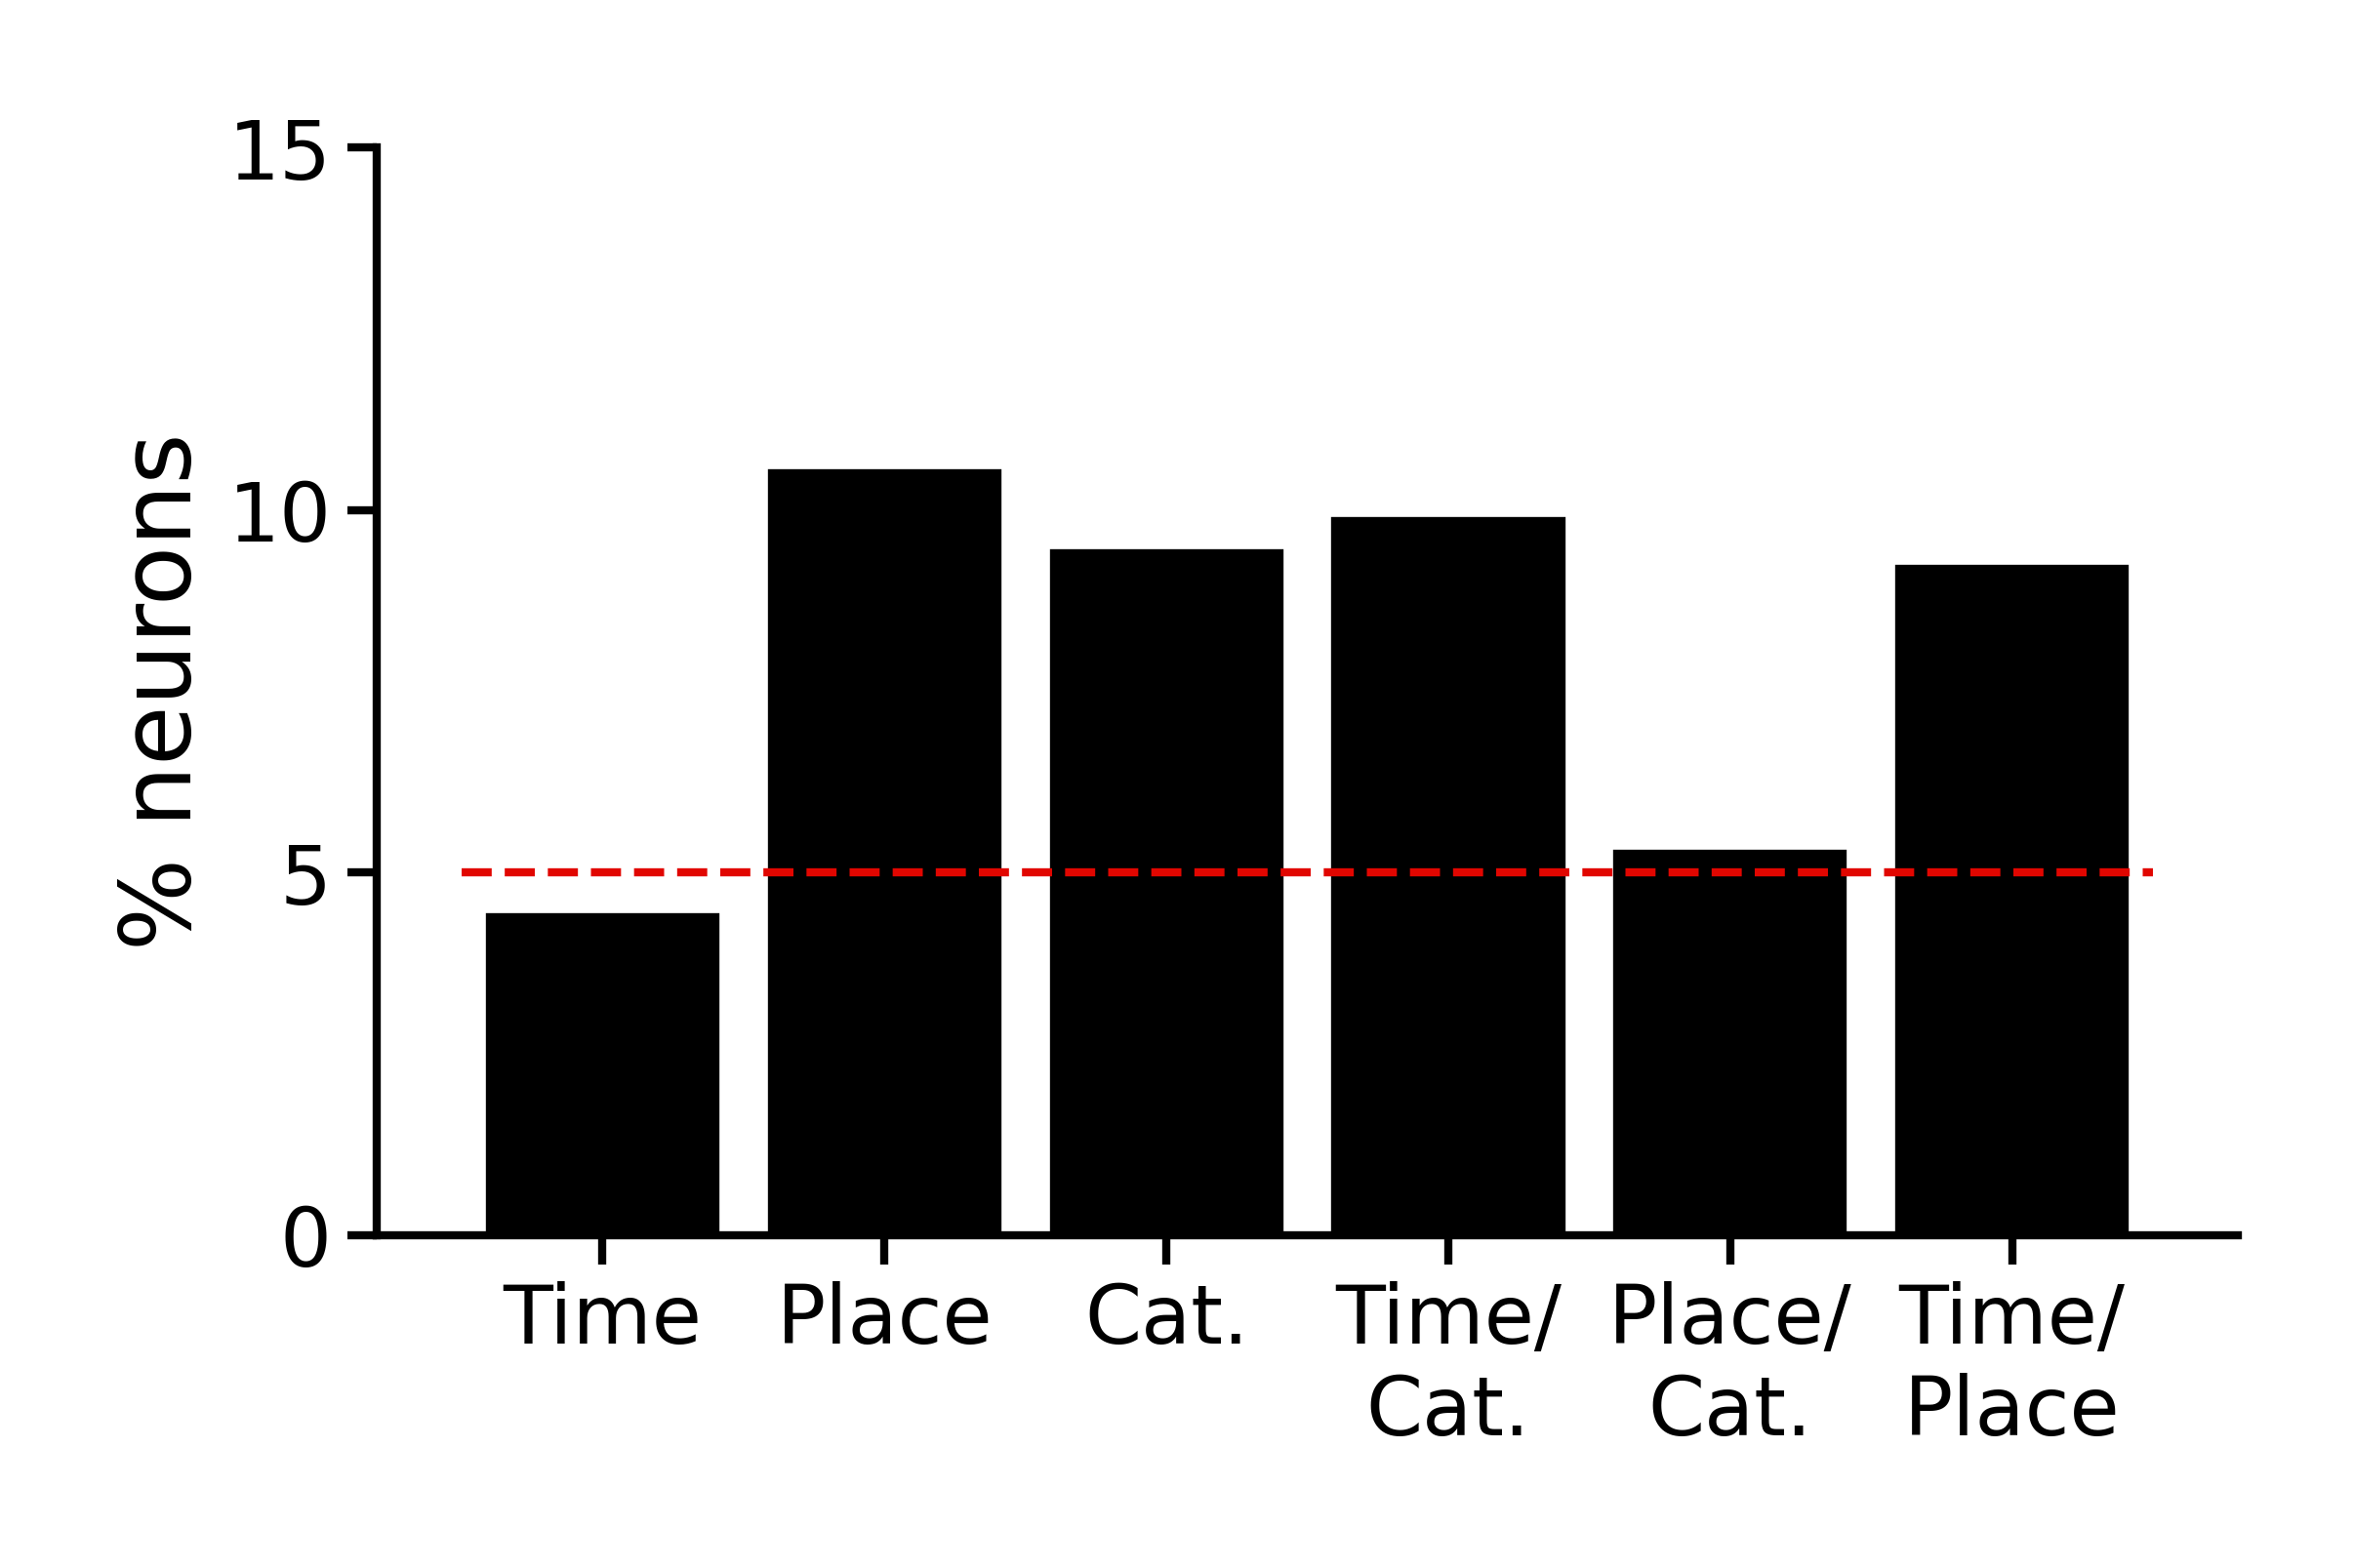

In [148]:
savefig = 0
overwrite = 0
sig_col = 'sig'
full = 'fullMax'
test_vars = ['max-time', 'max-place', 'max-gameState', 'max-gameState:time', 'max-gameState:place', 'max-time:place']
xcats = ['Time', 'Place', 'Cat.', 'Time/\nCat.', 'Place/\nCat.', 'Time/\nPlace']
ylim = [0, 15]
yticks = [0, 5, 10, 15]
figsize = (colws[1], colws[1] * 0.6)
font = {'tick': 5, 'label': 6, 'annot': 5}
spine_lw = 0.5
spine_len = 1.8
labelpad = 2

# Graph percent of units that code for each variable of interest.
_df = mod_pairs.query("(full=='{}')".format(full)).copy()
_df['testvar'] = _df['testvar'].astype(pd.CategoricalDtype(test_vars, ordered=True))
_df = _df.groupby(['testvar'], observed=True)['sig'].apply(lambda x: 100 * np.mean(x)).reset_index()

# Make the plot.
plt.close()
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=1200)
ax = sns.barplot(x='testvar', y='sig', color='k', data=_df, ax=ax,
                 saturation=1, linewidth=spine_lw, edgecolor='k')
ax.hlines(5, -0.5, len(test_vars) - 0.5, colors='#e10600', linestyles='dashed', lw=spine_lw)
for axis in ['left', 'bottom']:
    ax.spines[axis].set_linewidth(spine_lw)
ax.tick_params(labelsize=font['tick'], pad=1, length=spine_len, width=spine_lw)
ax.set_xticklabels(xcats, fontsize=font['tick'])
ax.set_ylim(ylim)
ax.set_yticks(yticks)
ax.set_yticklabels(yticks)
ax.set_xlabel('', fontsize=font['label'], labelpad=labelpad)
ax.set_ylabel('% neurons', fontsize=font['label'], labelpad=labelpad-1)

if savefig:
    n_units = np.unique(mod_pairs['subj_sess_unit']).size
    filename = op.join(proj_dir, 'figs', 'plot_navigation2',
                       'pct_sig-time_place_gameState_+interactions-{}units-fullMax.pdf'.format(n_units))
    if overwrite or not op.exists(filename):
        fig.savefig(filename, format='pdf', bbox_inches='tight')
            
fig.show();

# Single-cell examples: time, place, head direction, and view coding

In [13]:
# neurons = ['U518_ses0-4-1', 'U532_ses0-4-1', 'U530_ses0-13-1', 'U518_ses0-73-1', 'U518_ses1-38-1', 'U532_ses0-10-1',
#            'U532_ses0-5-8', 'U530_ses0-3-2', 'U526_ses0-12-2', 'U518_ses0-73-1', 'U527_ses0-58-2', 'U532_ses0-8-2',
#            'U518_ses1-43-2', 'U532_ses0-4-3', 'U532_ses0-3-2', 'U518_ses1-36-1']
# Time: 
# array(['U554_ses0-9-1', 'U554_ses0-39-1', 'U554_ses0-39-1',
       # 'U554_ses0-40-1', 'U554_ses0-40-1', 'U563_ses0-22-1',
       # 'U563_ses0-21-1', 'U563_ses0-21-1', 'U563_ses0-30-1',
       # 'U563_ses0-58-1', 'U563_ses0-58-1'], dtype='<U14')
# Time x gameState:
# array(['U554_ses0-6-1', 'U554_ses0-6-1', 'U554_ses0-9-1', 'U554_ses0-9-1',
#        'U554_ses0-10-2', 'U554_ses0-29-1', 'U554_ses0-29-1',
#        'U555_ses0-1-1', 'U555_ses0-1-1', 'U554_ses0-58-1',
#        'U555_ses0-11-1', 'U555_ses0-11-1', 'U563_ses0-31-1'], dtype='<U14')
# U554_ses0-10-2 and U554_ses0-58-1 weirdly similar responses

cell_name = 'U554_ses0-58-1'

print(f"{cell_name} → ROI: {mod_pairs.loc[mod_pairs['subj_sess_unit'] == cell_name, 'roi'].iloc[0]}, Hemisphere: {mod_pairs.loc[mod_pairs['subj_sess_unit'] == cell_name, 'hem'].iloc[0]}, ROI_gen: {mod_pairs.loc[mod_pairs['subj_sess_unit'] == cell_name, 'roi_gen'].iloc[0]}")


U554_ses0-58-1 → ROI: A, Hemisphere: R, ROI_gen: MTL


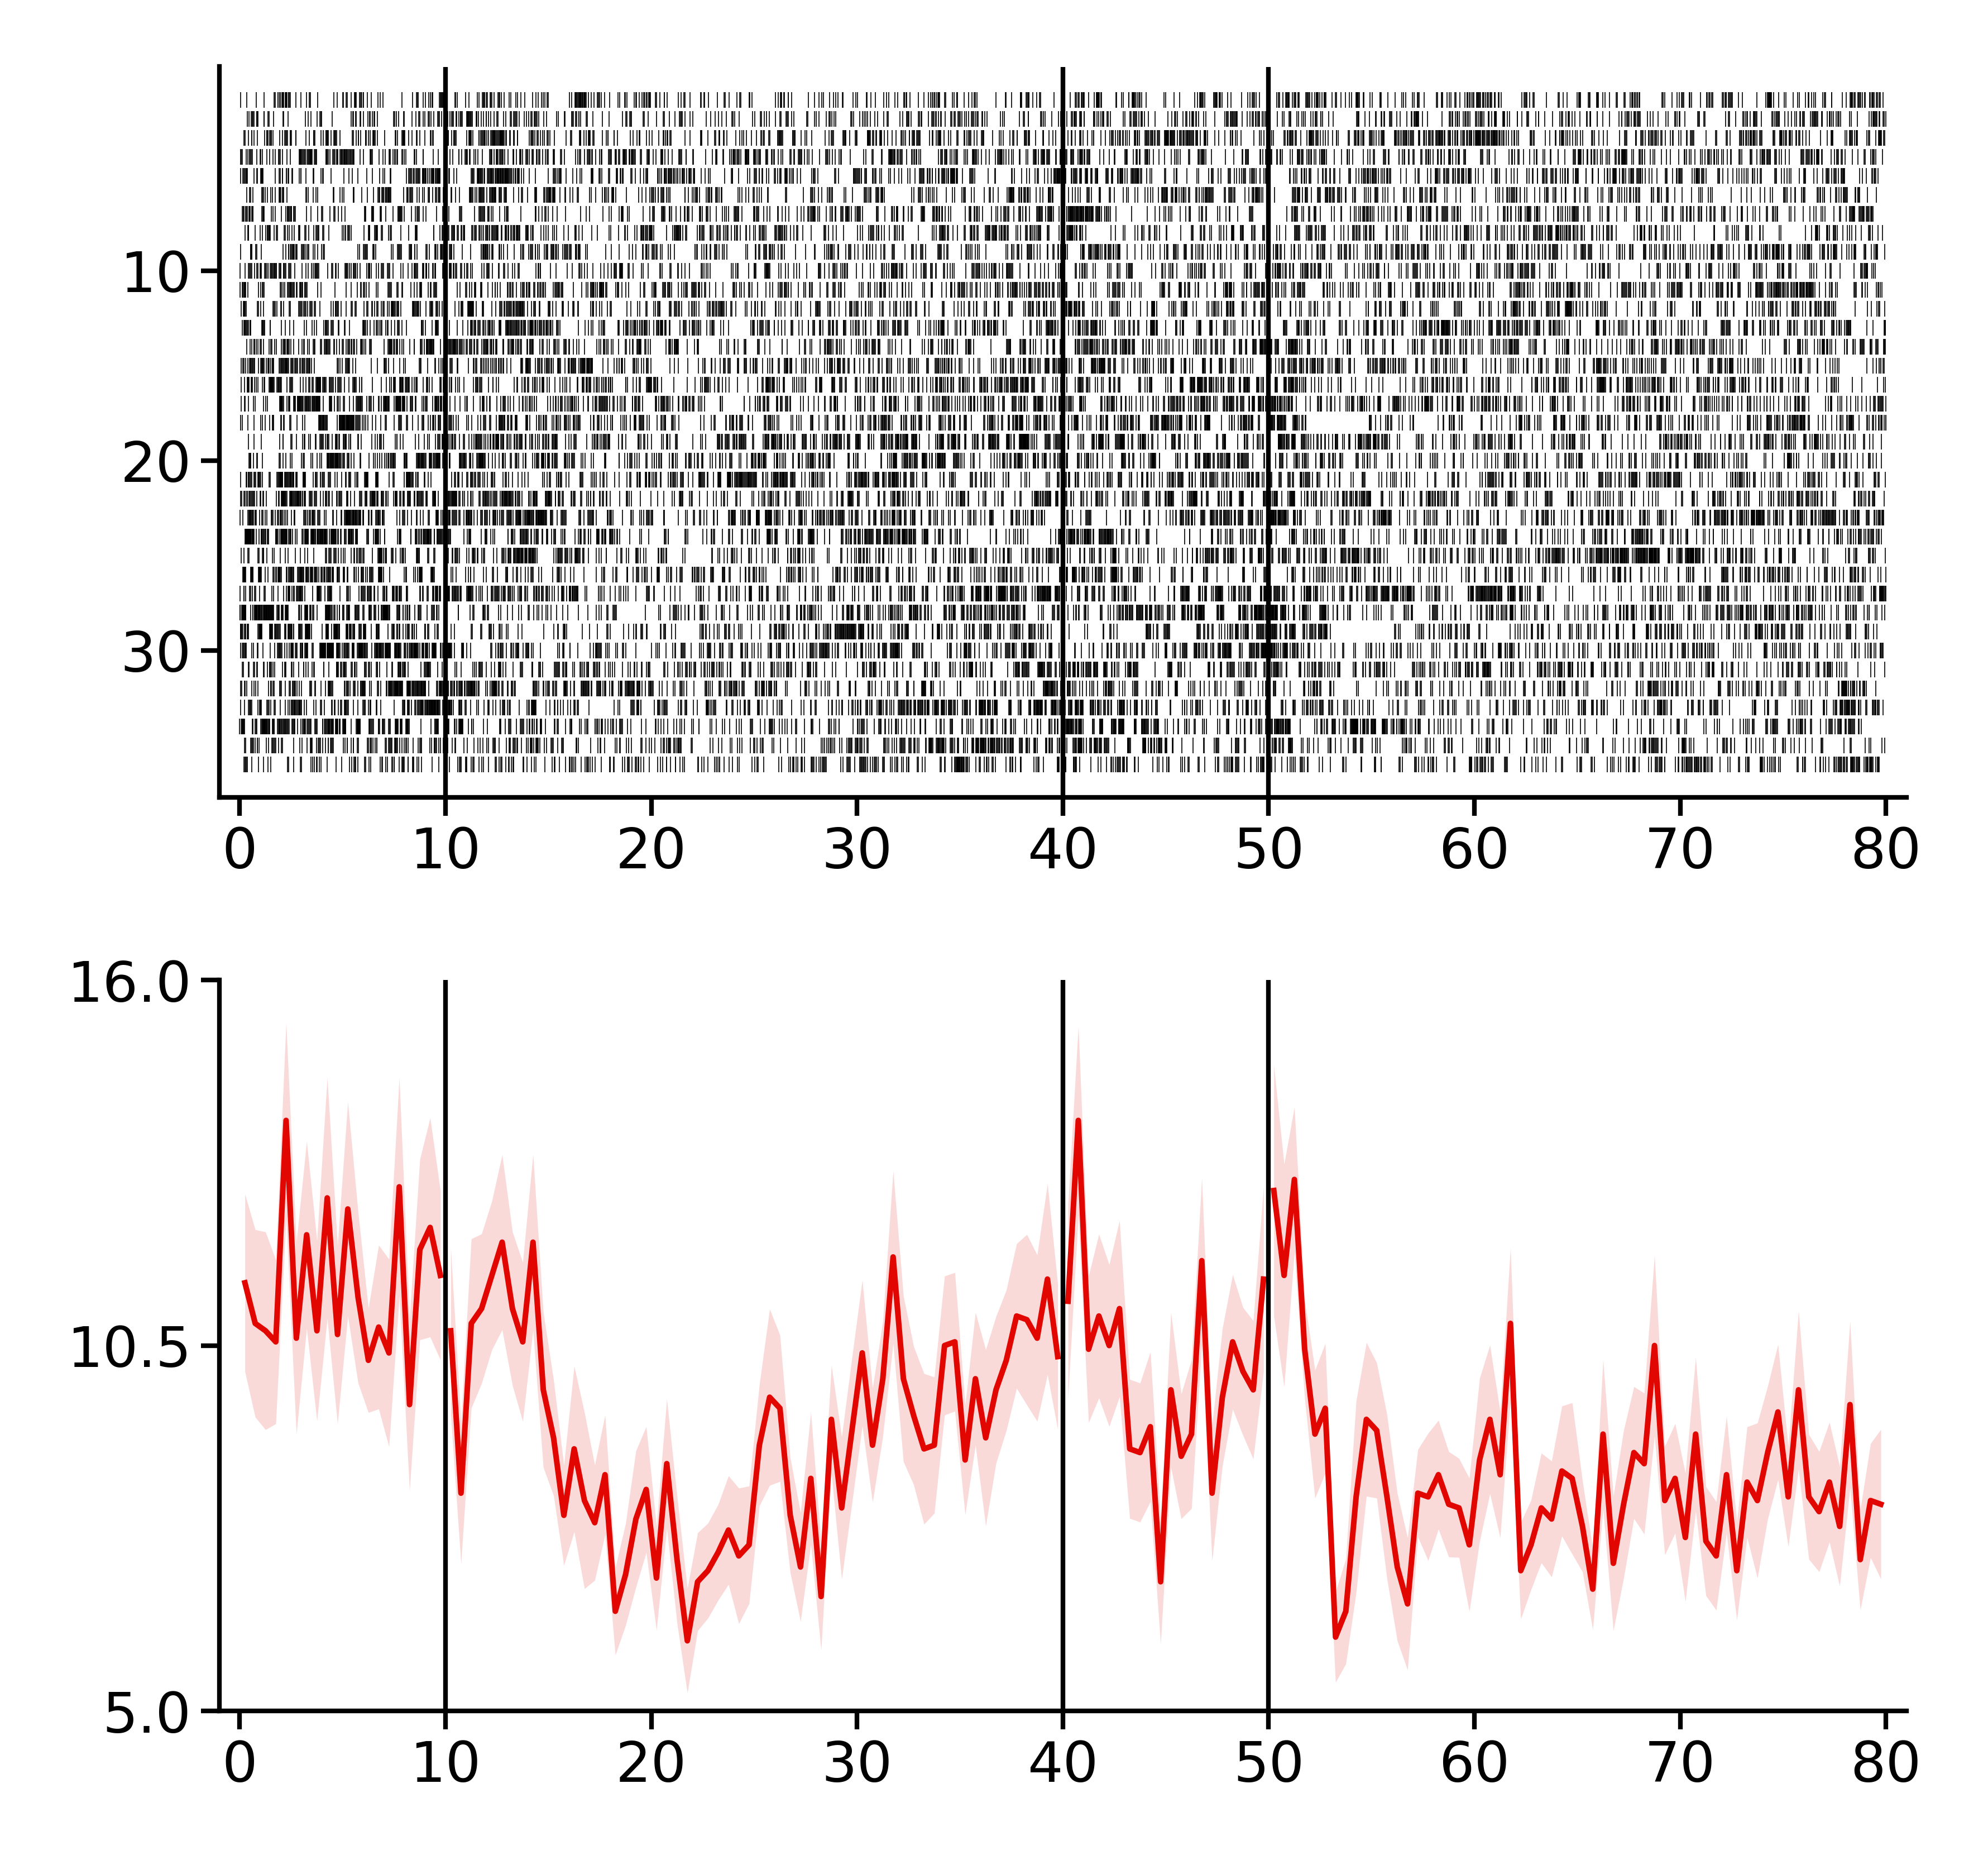

In [14]:
# Save raster and firing rate plots for chosen neuron.
subj_sess_unit = 'U554_ses0-58-1'
game_states = ['Delay1', 'Encoding', 'Delay2', 'Retrieval']
savefig = 0
overwrite = 1
figsize = (3.25, 3.25)
dpi = 1200
font = {'tick': 6, 'label': 8, 'annot': 8, 'fig': 9}
ax_linewidth = 0.5
labelpad = 2
plot_vlines = 1
plot_labels = 0
plot_game_states = 0
plot_title = 0
rastersize = 1.7
rasterwidth = 0.1

plt.close()
fig, ax = plt.subplots(2, 1, figsize=figsize, dpi=dpi)
ax = np.ravel(ax)

iax = 0
subj_sess = subj_sess_unit.split('-')[0]
neuron = '-'.join(subj_sess_unit.split('-')[1:])
ax[iax] = time_cell_plots.time_raster(subj_sess,
                                      neuron,
                                      game_states=game_states,
                                      plot_vlines=plot_vlines,
                                      plot_labels=plot_labels,
                                      plot_game_states=plot_game_states,
                                      plot_title=plot_title,
                                      proj_dir = '/data7/gemmine',
                                      ax=ax[iax],
                                      font=font,
                                      labelpad=labelpad,
                                      ax_linewidth=ax_linewidth,
                                      rastersize=rastersize,
                                      rasterwidth=rasterwidth)
iax += 1
ax[iax] = time_cell_plots.firing_rate_over_time(subj_sess,
                                                neuron,
                                                game_states=game_states,
                                                plot_vlines=plot_vlines,
                                                plot_labels=plot_labels,
                                                plot_game_states=plot_game_states,
                                                plot_title=plot_title,
                                                proj_dir = '/data7/gemmine',
                                                ax=ax[iax],
                                                font=font,
                                                labelpad=labelpad,
#                                                 ymin=1.5,
#                                                 ymax=1.5,
#                                                 yticks=[1, 3, 5],
                                                ax_linewidth=ax_linewidth)

if savefig:
    chan, unit = neuron.split('-')
    hemroi = spike_preproc.roi_lookup(subj_sess, chan)
    filename = op.join(proj_dir, 'figs', 'plot_rasters',
                       '{}-CSC{}-unit{}-{}-{}-raster.pdf'.format(subj_sess, chan, unit, hemroi, '_'.join(game_states)))
    if overwrite or not op.exists(filename):
        fig.savefig(filename, format='pdf', bbox_inches='tight')
            
fig.show()

In [15]:
# # Place:
# array(['U554_ses0-9-2', 'U563_ses0-16-1', 'U563_ses0-16-1',
#        'U563_ses0-22-1', 'U563_ses0-22-1', 'U563_ses0-41-1',
#        'U563_ses0-31-1', 'U563_ses0-31-1'], dtype='<U14')

units = ['U554_ses0-9-2', 'U563_ses0-16-1', 'U563_ses0-16-1',
       'U563_ses0-22-1', 'U563_ses0-22-1', 'U563_ses0-41-1',
       'U563_ses0-31-1', 'U563_ses0-31-1']
cols = ['subj_sess_unit', 'hem', 'roi', 'gameState', 'testvar', 'full', 'z_lr', 'emp_pval', 'sig_holm', 'fr_mean', 'fr_max']
# _units = ['U518_ses1-43-2', 'U521_ses0-21-1', 'U532_ses0-4-3']



In [16]:
mod_pairs.keys()
np.unique(mod_pairs['testvar'])
np.unique(mod_pairs['full'])

Index(['subj_sess_unit', 'subj', 'roi_gen', 'hem', 'roi', 'gameState',
       'testvar', 'full', 'red', 'llf_full', 'llf_red', 'df', 'lr', 'z_lr',
       'emp_pval', 'sig', 'sig01', 'sig_fdr', 'pvals_fdr'],
      dtype='object')

array(['gameState', 'gameState:place', 'gameState:time', 'max-gameState',
       'max-gameState:place', 'max-gameState:time', 'max-place',
       'max-time', 'max-time:place', 'place', 'time', 'time:place'],
      dtype=object)

array(['full', 'fullMax'], dtype=object)

# Time cell heatmaps

In [21]:
from sklearn.preprocessing import minmax_scale
from scipy.ndimage import gaussian_filter1d
from collections import defaultdict

# import needed functions from replay_functions in john_time_cells
get_spike_mat_unsmoothed, load_spikes_from_pkl, parse_neuron_name, _combine_time_bins, _rate_vec_cached, _mann_whitney= (
    rf[name] for name in ["get_spike_mat_unsmoothed", "load_spikes_from_pkl", "parse_neuron_name", "_combine_time_bins", "_rate_vec_cached", "_mann_whitney"]
)
from typing import Set,List

# defining this nonsig_neurons group if I want to select all NON time and place cells

exclude_vars = ['time', 'gameState:time', 'time:place',
                'place', 'gameState:place']
# Gather all significant neurons across the excluded vars
sig_excluded = set().union(*[sig_cells[v] for v in exclude_vars if v in sig_cells])
# Now get neurons in all_unit_list that are NOT significant in any of the excluded vars
non_sig_neurons = set(all_unit_list).difference(sig_excluded)

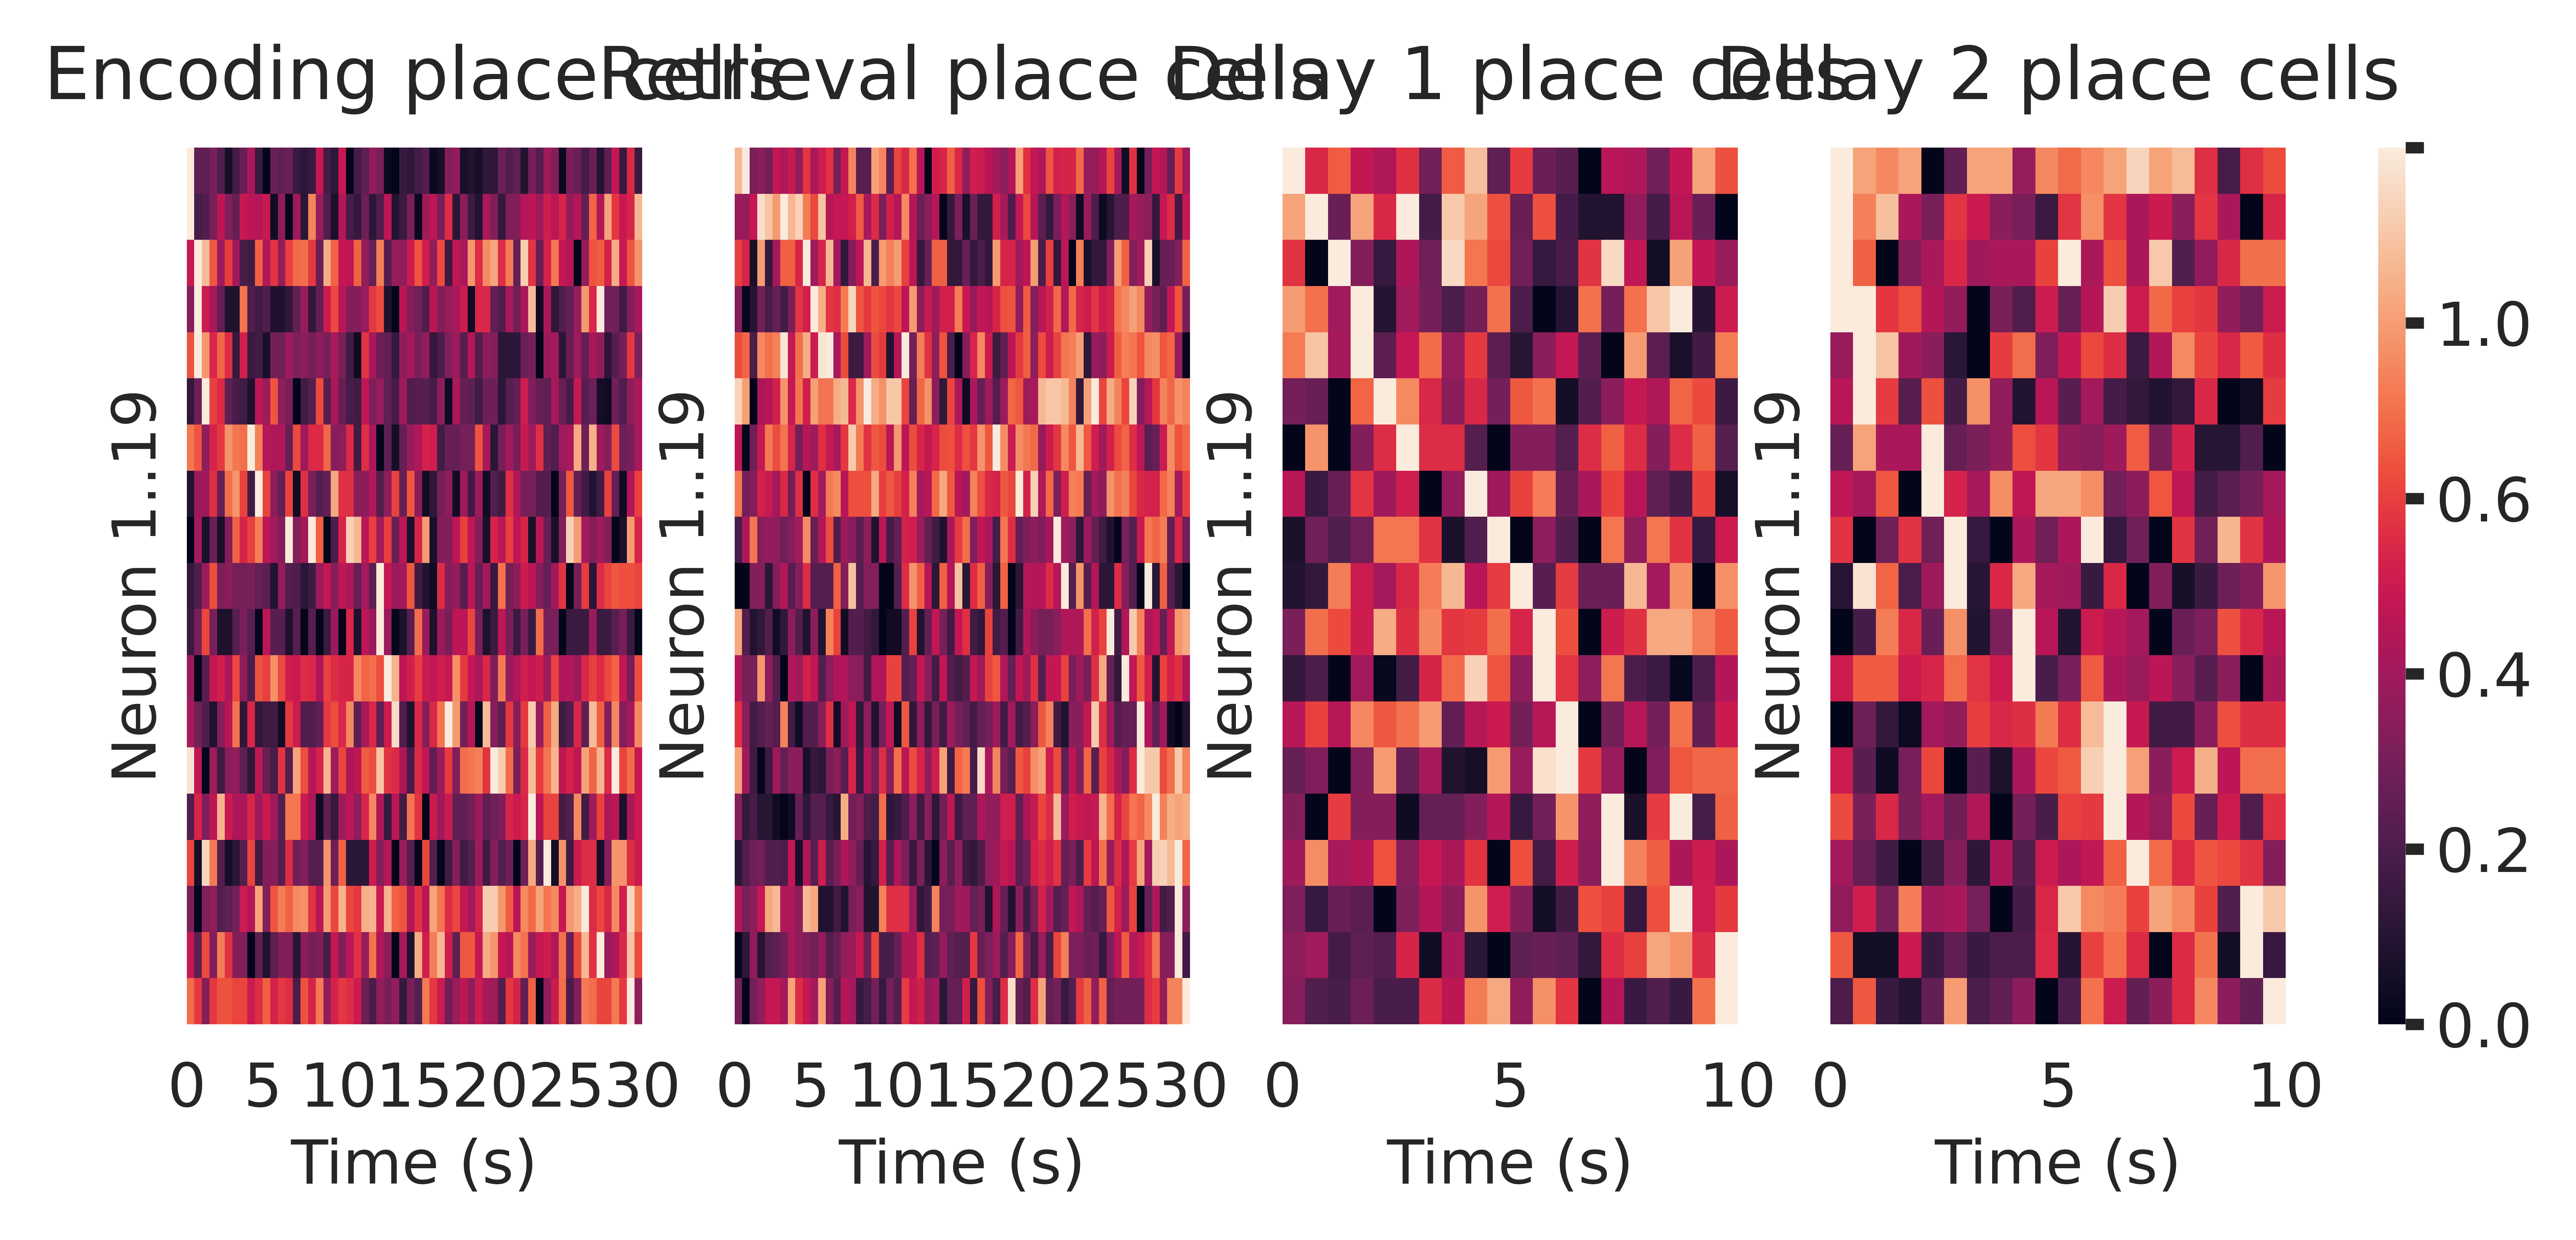

In [22]:
# === CONFIG ===
savefig = False
overwrite = False
grid_shp = (15, 37)
figsize = (colws['1'], colws['1'] * (grid_shp[0] / grid_shp[1]))
dpi = 1200
bins = 60
time_bin_width_sec = 0.5  # seconds per bin in combined PSTH
ALPHA_DELAY = 0.05  # selection threshold (two-sided)

# === NEURON SELECTION PARAMS ===

# select by cell type??

# testvars = ['time', 'gameState:time', 'time:place']
testvars = ['place', 'gameState:place']
# testvars = ['non_sig'] remaining nonsig cells # ['all'] # all cells
# testvars = ['all']
# testvars = ['delay_selective'] # per-neuron Mann–Whitney comparing Delay1+Delay2 vs Encoding+Retrieval (two-sided).
# testvars = ['delay2_vs_encoding'] #per-neuron Mann–Whitney comparing Delay2 vs Encoding (two-sided).
# testvars = ['NOT_delay_selective'] # opposite of delay selective for comparison
# testvars = ['navigation_selective']  # (Encoding+Retrieval) > (Delay1+Delay2), one-sided MWU
### This logic lets you request any combo, e.g. testvars = ['navigation_selective', 'NOT_delay_selective']
### (union of the two sets) but not intersection


#if you ever want to allow combining selectors (e.g., testvars = ['delay_selective','place']), 
# change the equality checks to membership, e.g. if 'delay_selective' in testvars: etc.

# region
roi_filter = ['HPC'] #['PFC','TPC'] #['HPC']#['HPC','MTL','PFC','TPC'] 
                    #['HPC','MTL'] # ['HPC','MTL','PFC','TPC'] used roi=4 in spike_preproc
                    # also added ['ERC'], ['AMY'], and ['PHG']

# hemisphere
hemisphere = ['ipsi'] # ['ipsi'] ['contra'], ['both']

# Flag: 0 = all, 1 = only Goldmine Concepts, 2 = only Gem Mine
use_Goldmine_Concepts_only = 0        
    
# order cells by moving average or raw data?
moving_avg = 0  # Set to None to disable. 3 looks nice

# === NEURON SELECTION PARAMS END ===

# changes what task phases plot in heatmaps below
game_states = ['Encoding', 'Retrieval','Delay1','Delay2']
# game_states = ['Encoding', 'Retrieval']


# === Get neurons_of_interest (fast, cached, and only compute what's needed) ===
neurons_of_interest: Set[str] = set()

want_delay_sel  = ('delay_selective' in testvars)
want_not_delay  = ('NOT_delay_selective' in testvars) 
want_d2_vs_enc  = ('delay2_vs_encoding' in testvars)
want_nav_sel    = ('navigation_selective' in testvars)

# compute comparison-based sets when needed
if want_delay_sel or want_not_delay or want_d2_vs_enc or want_nav_sel: 

    candidate_neurons: Set[str] = set(all_unit_list)

    delay_selective_neurons: Set[str] = set()
    delay2_vs_encoding_neurons: Set[str] = set()
    navigation_selective_neurons: Set[str] = set() 
    
    for neuron in candidate_neurons:

        # ---- delay_selective: (Delay1+Delay2) > (Encoding+Retrieval)
        if (want_delay_sel or want_not_delay):  # NEW: compute this set when we need its complement too
            r_d1 = _rate_vec_cached(neuron, 'Delay1', bins, time_bin_width_sec, proj_dir=proj_dir)
            r_d2 = _rate_vec_cached(neuron, 'Delay2', bins, time_bin_width_sec, proj_dir=proj_dir)
            r_e  = _rate_vec_cached(neuron, 'Encoding', bins, time_bin_width_sec, proj_dir=proj_dir)
            r_r  = _rate_vec_cached(neuron, 'Retrieval', bins, time_bin_width_sec, proj_dir=proj_dir)

            if (r_d1 is not None) and (r_d2 is not None) and (r_e is not None) and (r_r is not None):
                d12     = np.concatenate([r_d1, r_d2])
                enc_ret = np.concatenate([r_e,  r_r])

                # quick directional screen; skip MWU if direction is wrong
                if np.nanmedian(d12) > np.nanmedian(enc_ret):
                    _, p = _mann_whitney(d12, enc_ret, alternative="greater")
                    if p < ALPHA_DELAY:
                        delay_selective_neurons.add(neuron)

        # ---- delay2_vs_encoding: Delay2 > Encoding
        if want_d2_vs_enc:
            r_d2 = _rate_vec_cached(neuron, 'Delay2',   bins, time_bin_width_sec, proj_dir=proj_dir)
            r_e  = _rate_vec_cached(neuron, 'Encoding', bins, time_bin_width_sec, proj_dir=proj_dir)

            if (r_d2 is not None) and (r_e is not None):
                if np.nanmedian(r_d2) > np.nanmedian(r_e):
                    _, p = _mann_whitney(r_d2, r_e, alternative="greater")
                    if p < ALPHA_DELAY:
                        delay2_vs_encoding_neurons.add(neuron)
                        
        # ---- navigation_selective: (Encoding+Retrieval) > (Delay1+Delay2)
        if want_nav_sel:
            r_d1 = _rate_vec_cached(neuron, 'Delay1',   bins, time_bin_width_sec, proj_dir=proj_dir)
            r_d2 = _rate_vec_cached(neuron, 'Delay2',   bins, time_bin_width_sec, proj_dir=proj_dir)
            r_e  = _rate_vec_cached(neuron, 'Encoding', bins, time_bin_width_sec, proj_dir=proj_dir)
            r_r  = _rate_vec_cached(neuron, 'Retrieval',bins, time_bin_width_sec, proj_dir=proj_dir)

            if (r_d1 is not None) and (r_d2 is not None) and (r_e is not None) and (r_r is not None):
                d12     = np.concatenate([r_d1, r_d2])
                enc_ret = np.concatenate([r_e,  r_r])

                # quick directional screen; skip MWU if direction is wrong
                if np.nanmedian(enc_ret) > np.nanmedian(d12):
                    _, p = _mann_whitney(enc_ret, d12, alternative="greater")
                    if p < ALPHA_DELAY:
                        navigation_selective_neurons.add(neuron)                        

    # finalize selection
    selected_sets: List[Set[str]] = []

    if want_delay_sel:
        selected_sets.append(delay_selective_neurons)
    if want_d2_vs_enc:
        selected_sets.append(delay2_vs_encoding_neurons)
    if want_nav_sel:  # navigation_selective
        selected_sets.append(navigation_selective_neurons)

    if want_not_delay:
        # complement of delay_selective within the candidate pool
        selected_sets.append(candidate_neurons.difference(delay_selective_neurons))

    if selected_sets:
        # union of any requested selectors
        neurons_of_interest = set().union(*selected_sets)
    else:
        # Original behavior for legacy keywords in `testvars`
        for tv in testvars:
            if tv == 'non_sig':
                neurons_of_interest.update(non_sig_neurons)
            elif tv == 'all':
                neurons_of_interest.update(set(all_unit_list))
            else:
                neurons_of_interest.update(sig_cells[tv])

else:
    # Original behavior
    for testvar in testvars:
        if testvar == 'non_sig':
            neurons_of_interest.update(non_sig_neurons)
        elif testvar == 'all':
            neurons_of_interest.update(set(all_unit_list))
        else:
            neurons_of_interest.update(sig_cells[testvar])

            
# Use ROI info in mod_pairs to filter general regions using those defined in roi_filter
if roi_filter == ['ERC']:
    filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['EC'])]
elif roi_filter == ['AMY']:
    filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['A'])]
elif roi_filter == ['PHG']:
    filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['PH','PHG','PHGp','SUB-PHG'])]
else:
    filtered_mod_pairs = mod_pairs[mod_pairs['roi_gen'].isin(roi_filter)]
neurons_in_filtered_rois = set(filtered_mod_pairs['subj_sess_unit'].unique())
neurons_of_interest = neurons_of_interest.intersection(neurons_in_filtered_rois)


# === BUILD spike matrix ===
spikes_by_time = od({gs: [] for gs in game_states})
neuron_order = od({gs: [] for gs in game_states})  # track the order of neurons
sorted_neuron_lists = {gs: [] for gs in game_states} # To store sorted neuron names for each game_state

for game_state in game_states:
    for neuron in neurons_of_interest:
        try:
            rate_hz = _rate_vec_cached(neuron, game_state, bins, time_bin_width_sec, proj_dir=proj_dir)
            if rate_hz is not None:
                spikes_by_time[game_state].append(rate_hz)
                neuron_order[game_state].append(neuron)
        except Exception as e:
            print(f"Skipping {neuron} for {game_state}: {e}")

for gs in game_states:
    spikes_by_time[gs] = np.array(spikes_by_time[gs])
    

# === PLOT (dynamic panels + single shared colorbar) ===
import matplotlib.gridspec as gridspec

plt.close()
n_states = len(game_states)
fig = plt.figure(figsize=figsize, dpi=dpi)

# panels for each state + a skinny colorbar column at the end
gs = fig.add_gridspec(nrows=1, ncols=n_states + 1, width_ratios=[1]*n_states + [0.06])
axes = [fig.add_subplot(gs[0, i]) for i in range(n_states)]
cbar_ax = fig.add_subplot(gs[0, -1])

font = {'tick': 10, 'label': 10, 'annot': 10, 'fig': 12}

# Titles that adapt to your selected testvars (feel free to tweak wording)
if testvars == ['time', 'gameState:time', 'time:place']:
    base_titles = {'Encoding': 'Encoding time cells', 'Retrieval': 'Retrieval time cells',
                   'Delay1': 'Delay 1 time cells', 'Delay2': 'Delay 2 time cells'}
elif testvars == ['place', 'gameState:place']:
    base_titles = {'Encoding': 'Encoding place cells', 'Retrieval': 'Retrieval place cells',
                   'Delay1': 'Delay 1 place cells', 'Delay2': 'Delay 2 place cells'}   
elif testvars == ['non_sig']:
    base_titles = {'Encoding': 'Encoding other cells', 'Retrieval': 'Retrieval other cells',
                   'Delay1': 'Delay 1 other cells', 'Delay2': 'Delay 2 other cells'}
else: # testvars == ['delay_selective'] or testvars == ['delay2_vs_encoding']:
    base_titles = {'Encoding': 'Encoding', 'Retrieval': 'Retrieval',
                   'Delay1': 'Delay 1', 'Delay2': 'Delay 2'}   

n_neurons_by_state = {}

for i, game_state in enumerate(game_states):
    ax_i = axes[i]
    fr_raw = spikes_by_time[game_state]  # shape: neurons x time (or empty)

    # Handle empty state gracefully
    if fr_raw.size == 0:
        sorted_neuron_lists[game_state] = []  # <-- ensure key exists
        print(f"No neurons for {game_state}; skipping heatmap.")
        ax_i.set_axis_off()
        ax_i.set_title(f"{base_titles.get(game_state, game_state)}\n(no neurons)", fontsize=font['fig'], pad=8)
        continue


    neuron_ids = np.array(neuron_order[game_state])

    # Optional smoothing
    if moving_avg and moving_avg > 1:
        kernel = np.ones(moving_avg) / moving_avg
        fr_smooth = np.array([np.convolve(row, kernel, mode='same') for row in fr_raw])
    else:
        fr_smooth = fr_raw

    # Normalize per neuron
    fr_norm = minmax_scale(fr_smooth, axis=1)
    # Sort by peak bin
    peak_bins = np.argmax(fr_norm, axis=1)
    xsort = np.argsort(peak_bins)
    sorted_peak_bins = peak_bins[xsort]
    fr_mat = fr_norm[xsort, :]
    n_neurons_by_state[game_state] = fr_mat.shape[0]

    # Track sorted neurons + peak times for downstream use
    sorted_neurons = neuron_ids[xsort]
    sorted_peak_times_sec = sorted_peak_bins * time_bin_width_sec
    sorted_neuron_lists[game_state] = [
        {"neuron": n, "peak_time_sec": float(t)}
        for n, t in zip(sorted_neurons, sorted_peak_times_sec)
    ]

    # Heatmap
    n_bins = fr_mat.shape[1]
    xticks = np.arange(0, n_bins + 1, 10)
    xticklabels = (xticks * time_bin_width_sec).astype(int)

    add_cbar = (i == n_states - 1)  # only on the last panel
    hm = sns.heatmap(
        fr_mat, ax=ax_i, vmin=0, vmax=1, cmap='rocket',
        square=False, cbar=add_cbar, cbar_ax=cbar_ax if add_cbar else None
    )

    ax_i.tick_params(axis='x', which='both', length=3, pad=3)
    ax_i.tick_params(axis='y', which='both', length=0, pad=3)
    ax_i.set_xticks(xticks)
    ax_i.set_xticklabels(xticklabels, fontsize=font['tick'], rotation=0)
    ax_i.set_xlabel('Time (s)', fontsize=font['label'], labelpad=3)
    ax_i.set_yticks([])
    ax_i.set_ylabel(f'Neuron 1..{n_neurons_by_state[game_state]}', fontsize=font['label'], labelpad=3)
    ax_i.set_title(base_titles.get(game_state, f"{game_state} cells"), pad=8, fontsize=font['fig'])

# Style the shared colorbar if present
if np.any([spikes_by_time[gs].size > 0 for gs in game_states]):
    cbar = axes[-1].collections[0].colorbar
    cbar.ax.tick_params(labelsize=font['tick'], length=3, pad=2)
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.set_ticklabels([0.0, 0.2, 0.4, 0.6, 1.0])

# === SAVE ===
if savefig:
    label = '-'.join([tv.replace(':', '') for tv in testvars])
    counts_str = '-'.join([f"{gs.lower()}-{n_neurons_by_state.get(gs, 0)}" for gs in game_states])
    filename = op.join(
        proj_dir, 'figs', 'plot_navigation',
        f'navigation_time_cells-{label}-{counts_str}-total-{len(neurons_of_interest)}.pdf'
    )
    if overwrite or not op.exists(filename):
        fig.savefig(filename, format='pdf', bbox_inches='tight', pad_inches=0)
        fig.savefig(filename.replace('pdf', 'png'), format='png', dpi=dpi, bbox_inches='tight', pad_inches=0)

fig.show();

# # === CONFIG ===
# savefig = False
# overwrite = False
# grid_shp = (15, 37)
# figsize = (colws['1'], colws['1'] * (grid_shp[0] / grid_shp[1]))
# dpi = 1200
# bins = 60
# time_bin_width_sec = 0.5  # seconds per bin in combined PSTH

# # === NEURON SELECTION PARAMS ===

# # select by cell type??

# # testvars = ['time', 'gameState:time', 'time:place']
# # testvars = ['place', 'gameState:place']
# # testvars = ['non_sig'] remaining nonsig cells # ['all'] # all cells
# testvars = ['all']

# # region
# roi_filter = ['ERC'] #['PFC','TPC'] #['HPC']#['HPC','MTL','PFC','TPC'] 
#                     #['HPC','MTL'] # ['HPC','MTL','PFC','TPC'] used roi=4 in spike_preproc
#                     # also added ['ERC'], ['AMY'], and ['PHG']

# # hemisphere
# hemisphere = ['ipsi'] # ['ipsi'] ['contra'], ['both']

# # Flag: 0 = all, 1 = only Goldmine Concepts, 2 = only Gem Mine
# use_Goldmine_Concepts_only = 0        
    
# # order cells by moving average or raw data?
# moving_avg = 0  # Set to None to disable. 3 looks nice

# # === NEURON SELECTION PARAMS END ===


# # changes what task phases plot in heatmaps below
# game_states = ['Encoding', 'Retrieval']

# # === Get unique neurons that are significant in any of the testvars ===
# neurons_of_interest = set()
# for testvar in testvars:
#     if testvar == 'non_sig':
#         neurons_of_interest.update(non_sig_neurons)
#     elif testvar == 'all':
#         neurons_of_interest.update(set(all_unit_list))
#     else:
#         neurons_of_interest.update(sig_cells[testvar])
    
# # Use ROI info in mod_pairs to filter general regions using those defined in roi_filter
# if roi_filter == ['ERC']:
#     filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['EC'])]
# elif roi_filter == ['AMY']:
#     filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['A'])]
# elif roi_filter == ['PHG']:
#     filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['PH','PHG','PHGp','SUB-PHG'])]
# else:
#     filtered_mod_pairs = mod_pairs[mod_pairs['roi_gen'].isin(roi_filter)]
# neurons_in_filtered_rois = set(filtered_mod_pairs['subj_sess_unit'].unique())
# neurons_of_interest = neurons_of_interest.intersection(neurons_in_filtered_rois)


# # === BUILD spike matrix ===
# spikes_by_time = od({gs: [] for gs in game_states})
# neuron_order = od({gs: [] for gs in game_states})  # track the order of neurons
# sorted_neuron_lists = {}  # To store sorted neuron names for each game_state

# for game_state in game_states:
#     for neuron in neurons_of_interest:
#         try:
#             spike_mat = get_spike_mat_unsmoothed(neuron, game_state,proj_dir = "/data7/gemmine/")
#             if spike_mat is not None:
#                 combined = _combine_time_bins(spike_mat, bins=bins)
#                 if combined is not None:
#                     spikes_by_time[game_state].append(combined)
#                     neuron_order[game_state].append(neuron)  # track order
#         except Exception as e:
#             print(f"Skipping {neuron} for {game_state}: {e}")

# for gs in game_states:
#     spikes_by_time[gs] = np.array(spikes_by_time[gs])

# # === PLOT ===
# plt.close()
# fig = plt.figure(figsize=figsize, dpi=dpi)
# ax = [
#     plt.subplot2grid(grid_shp, (0, 0), rowspan=grid_shp[0], colspan=15),
#     plt.subplot2grid(grid_shp, (0, 18), rowspan=grid_shp[0], colspan=15),
#     plt.subplot2grid(grid_shp, (0, 35), rowspan=grid_shp[0], colspan=2),
# ]
# ax = np.ravel(ax)

# font = {'tick': 10, 'label': 10, 'annot': 10, 'fig': 12}
# if testvars == ['time', 'gameState:time', 'time:place']:
#     ax_titles = {'Encoding': 'Encoding time cells', 'Retrieval': 'Retrieval time cells'}
# elif testvars == ['place', 'gameState:place']:
#     ax_titles = {'Encoding': 'Encoding place cells', 'Retrieval': 'Retrieval place cells'}
# else:
#     ax_titles = {'Encoding': 'Encoding other cells', 'Retrieval': 'Retrieval other cells'}
    
# n_neurons = []

# for i, game_state in enumerate(game_states):
#     fr_raw = spikes_by_time[game_state]  # shape: neurons x time
#     neuron_ids = np.array(neuron_order[game_state]) # assumes spikes_by_time order matches this
    
#     if moving_avg and moving_avg > 1:
#         kernel = np.ones(moving_avg) / moving_avg
#         # Smooth before normalization
#         fr_smooth = np.array([
#             np.convolve(row, kernel, mode='same') for row in fr_raw
#         ])
#     else:
#         fr_smooth = fr_raw

#     # Normalize after smoothing
#     fr_norm = minmax_scale(fr_smooth, axis=1)

#     # Find peak bin for each neuron
#     peak_bins = np.argmax(fr_norm, axis=1)
#     xsort = np.argsort(peak_bins)
#     sorted_peak_bins = peak_bins[xsort]

#     fr_mat = fr_norm[xsort, :]
#     n_neurons.append(fr_mat.shape[0])

#     # keep sorted neuron names
#     sorted_neurons = neuron_ids[xsort]

#     # Convert peak bin index to seconds
#     sorted_peak_times_sec = sorted_peak_bins * time_bin_width_sec

#     # Save neuron names and peak times together
#     sorted_neuron_lists[game_state] = [
#         {
#             "neuron": neuron_name,
#             "peak_time_sec": float(peak_time)
#         }
#         for neuron_name, peak_time in zip(sorted_neurons, sorted_peak_times_sec)
#     ]

#     # Plot
#     n_bins = fr_mat.shape[1]
#     xticks = np.arange(0, n_bins + 1, 10)
#     xticklabels = (xticks * time_bin_width_sec).astype(int)

#     add_cbar = i == len(ax) - 2

#     ax[i] = sns.heatmap(fr_mat, ax=ax[i], vmin=0, vmax=1, cmap='rocket',
#                         square=False, cbar=add_cbar, cbar_ax=ax[i + 1] if add_cbar else None)

#     ax[i].tick_params(axis='x', which='both', length=3, pad=3)
#     ax[i].tick_params(axis='y', which='both', length=0, pad=3)
#     ax[i].set_xticks(xticks)
#     ax[i].set_xticklabels(xticklabels, fontsize=font['tick'], rotation=0)
#     ax[i].set_xlabel('Time (s)', fontsize=font['label'], labelpad=3)
#     ax[i].set_yticks([])
#     ax[i].set_ylabel(f'Neuron 1..{n_neurons[-1]}', fontsize=font['label'], labelpad=3)
#     ax[i].set_title(ax_titles[game_state], pad=8, fontsize=font['fig'])

#     if add_cbar:
#         cbar = ax[i].collections[0].colorbar
#         cbar.ax.tick_params(labelsize=font['tick'], length=3, pad=2)
#         cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
#         cbar.set_ticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])


# # === SAVE ===
# if savefig:
#     label = '-'.join([tv.replace(':', '') for tv in testvars])
#     filename = op.join(proj_dir, 'figs', 'plot_navigation',
#                        f'navigation_time_cells-{label}-encoding-{n_neurons[0]}-retrieval-{n_neurons[1]}-total-{len(neurons_of_interest)}.pdf')
#     if overwrite or not op.exists(filename):
#         fig.savefig(filename, format='pdf', bbox_inches='tight', pad_inches=0)
#         fig.savefig(filename.replace('pdf', 'png'), format='png', dpi=dpi, bbox_inches='tight', pad_inches=0)

# fig.show();


# # === CONFIG ===
# savefig = False
# overwrite = False
# grid_shp = (15, 37)
# figsize = (colws['1'], colws['1'] * (grid_shp[0] / grid_shp[1]))
# dpi = 1200
# bins = 60
# time_bin_width_sec = 0.5  # seconds per bin in combined PSTH

# # === NEURON SELECTION PARAMS ===

# # select by cell type??

# # testvars = ['time', 'gameState:time', 'time:place']
# # testvars = ['place', 'gameState:place']
# # testvars = ['non_sig'] remaining nonsig cells # ['all'] # all cells
# testvars = ['all']

# # region
# roi_filter = ['ERC'] #['PFC','TPC'] #['HPC']#['HPC','MTL','PFC','TPC'] 
#                     #['HPC','MTL'] # ['HPC','MTL','PFC','TPC'] used roi=4 in spike_preproc
#                     # also added ['ENT'], ['AMY'], and ['PHG']

# # hemisphere
# hemisphere = ['ipsi'] # ['ipsi'] ['contra'], ['both']
        
# # order cells by moving average or raw data?
# moving_avg = 0  # Set to None to disable. 3 looks nice

# # changes what task phases plot in heatmaps below
# game_states = ['Encoding', 'Retrieval']

# # === Get unique neurons that are significant in any of the testvars ===
# neurons_of_interest = set()
# for testvar in testvars:
#     if testvar == 'non_sig':
#         neurons_of_interest.update(non_sig_neurons)
#     elif testvar == 'all':
#         neurons_of_interest.update(set(all_unit_list))
#     else:
#         neurons_of_interest.update(sig_cells[testvar])
    
# # Use ROI info in mod_pairs to filter general regions using those defined in roi_filter
# if roi_filter == ['ERC']:
#     filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['EC'])]
# elif roi_filter == ['AMY']:
#     filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['A'])]
# elif roi_filter == ['PHG']:
#     filtered_mod_pairs = mod_pairs[mod_pairs['roi'].isin(['PH','PHG','PHGp','SUB-PHG'])]
# else:
#     filtered_mod_pairs = mod_pairs[mod_pairs['roi_gen'].isin(roi_filter)]
# neurons_in_filtered_rois = set(filtered_mod_pairs['subj_sess_unit'].unique())
# neurons_of_interest = neurons_of_interest.intersection(neurons_in_filtered_rois)

# # === BUILD spike matrix ===
# spikes_by_time = od({gs: [] for gs in game_states})
# neuron_order = od({gs: [] for gs in game_states})  # track the order of neurons
# sorted_neuron_lists = {}  # To store sorted neuron names for each game_state

# for game_state in game_states:
#     for neuron in neurons_of_interest:
#         try:
#             spike_mat = get_spike_mat_unsmoothed(neuron, game_state,proj_dir = "/data7/goldmine/")
#             if spike_mat is not None:
#                 combined = _combine_time_bins(spike_mat, bins=bins)
#                 if combined is not None:
#                     spikes_by_time[game_state].append(combined)
#                     neuron_order[game_state].append(neuron)  # track order
#         except Exception as e:
#             print(f"Skipping {neuron} for {game_state}: {e}")

# for gs in game_states:
#     spikes_by_time[gs] = np.array(spikes_by_time[gs])

# # === PLOT ===
# plt.close()
# fig = plt.figure(figsize=figsize, dpi=dpi)
# ax = [
#     plt.subplot2grid(grid_shp, (0, 0), rowspan=grid_shp[0], colspan=15),
#     plt.subplot2grid(grid_shp, (0, 18), rowspan=grid_shp[0], colspan=15),
#     plt.subplot2grid(grid_shp, (0, 35), rowspan=grid_shp[0], colspan=2),
# ]
# ax = np.ravel(ax)

# font = {'tick': 10, 'label': 10, 'annot': 10, 'fig': 12}
# if testvars == ['time', 'gameState:time', 'time:place']:
#     ax_titles = {'Encoding': 'Encoding time cells', 'Retrieval': 'Retrieval time cells'}
# elif testvars == ['place', 'gameState:place']:
#     ax_titles = {'Encoding': 'Encoding place cells', 'Retrieval': 'Retrieval place cells'}
# else:
#     ax_titles = {'Encoding': 'Encoding other cells', 'Retrieval': 'Retrieval other cells'}
    
# n_neurons = []

# for i, game_state in enumerate(game_states):
#     fr_raw = spikes_by_time[game_state]  # shape: neurons x time
#     neuron_ids = np.array(neuron_order[game_state]) # assumes spikes_by_time order matches this
    
#     if moving_avg and moving_avg > 1:
#         kernel = np.ones(moving_avg) / moving_avg
#         # Smooth before normalization
#         fr_smooth = np.array([
#             np.convolve(row, kernel, mode='same') for row in fr_raw
#         ])
#     else:
#         fr_smooth = fr_raw

#     # Normalize after smoothing
#     fr_norm = minmax_scale(fr_smooth, axis=1)

#     # Find peak bin for each neuron
#     peak_bins = np.argmax(fr_norm, axis=1)
#     xsort = np.argsort(peak_bins)
#     sorted_peak_bins = peak_bins[xsort]

#     fr_mat = fr_norm[xsort, :]
#     n_neurons.append(fr_mat.shape[0])

#     # keep sorted neuron names
#     sorted_neurons = neuron_ids[xsort]

#     # Convert peak bin index to seconds
#     sorted_peak_times_sec = sorted_peak_bins * time_bin_width_sec

#     # Save neuron names and peak times together
#     sorted_neuron_lists[game_state] = [
#         {
#             "neuron": neuron_name,
#             "peak_time_sec": float(peak_time)
#         }
#         for neuron_name, peak_time in zip(sorted_neurons, sorted_peak_times_sec)
#     ]

#     # Plot
#     n_bins = fr_mat.shape[1]
#     xticks = np.arange(0, n_bins + 1, 10)
#     xticklabels = (xticks * time_bin_width_sec).astype(int)

#     add_cbar = i == len(ax) - 2

#     ax[i] = sns.heatmap(fr_mat, ax=ax[i], vmin=0, vmax=1, cmap='rocket',
#                         square=False, cbar=add_cbar, cbar_ax=ax[i + 1] if add_cbar else None)

#     ax[i].tick_params(axis='x', which='both', length=3, pad=3)
#     ax[i].tick_params(axis='y', which='both', length=0, pad=3)
#     ax[i].set_xticks(xticks)
#     ax[i].set_xticklabels(xticklabels, fontsize=font['tick'], rotation=0)
#     ax[i].set_xlabel('Time (s)', fontsize=font['label'], labelpad=3)
#     ax[i].set_yticks([])
#     ax[i].set_ylabel(f'Neuron 1..{n_neurons[-1]}', fontsize=font['label'], labelpad=3)
#     ax[i].set_title(ax_titles[game_state], pad=8, fontsize=font['fig'])

#     if add_cbar:
#         cbar = ax[i].collections[0].colorbar
#         cbar.ax.tick_params(labelsize=font['tick'], length=3, pad=2)
#         cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
#         cbar.set_ticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])


# # === SAVE ===
# if savefig:
#     label = '-'.join([tv.replace(':', '') for tv in testvars])
#     filename = op.join(proj_dir, 'figs', 'plot_navigation',
#                        f'navigation_time_cells-{label}-encoding-{n_neurons[0]}-retrieval-{n_neurons[1]}-total-{len(neurons_of_interest)}.pdf')
#     if overwrite or not op.exists(filename):
#         fig.savefig(filename, format='pdf', bbox_inches='tight', pad_inches=0)
#         fig.savefig(filename.replace('pdf', 'png'), format='png', dpi=dpi, bbox_inches='tight', pad_inches=0)

# fig.show();


# Let's look for replay in Delay2 of encoding time cells

In [23]:
# print("Encoding sorted neurons:", sorted_neuron_lists['Encoding'][:5])
# print("Retrieval sorted neurons:", sorted_neuron_lists['Retrieval'][:5])
peak_times_encoding = np.array([d['peak_time_sec'] for d in sorted_neuron_lists['Encoding']])
peak_neurons_encoding = np.array([d['neuron'] for d in sorted_neuron_lists['Encoding']])
peak_times_encoding
peak_neurons_encoding

# get the pairs of time cells with peaks in order of encoding fields

peak_neurons_encoding = np.array([d['neuron'] for d in sorted_neuron_lists['Encoding']])
peak_times_encoding = np.array([d['peak_time_sec'] for d in sorted_neuron_lists['Encoding']])

# 1. Group neurons by session
sessions = np.array([n.split('-')[0] for n in peak_neurons_encoding])
session_neurons = defaultdict(list)

for neuron, peak_time, session in zip(peak_neurons_encoding, peak_times_encoding, sessions):
    session_neurons[session].append((neuron, peak_time))
    
# Map neurons to hemisphere (from mod_pairs)
neuron_to_hem = mod_pairs.set_index('subj_sess_unit')['hem'].to_dict()    


array([ 0. ,  0. ,  0.5,  0.5,  0.5,  1. ,  4. ,  4.5,  6.5, 12.5, 12.5,
       13. , 17. , 20. , 22.5, 23.5, 26. , 27. , 29. ])

array(['U540_ses0-50-3', 'U532_ses0-8-2', 'U536_ses0-15-1',
       'U532_ses0-5-5', 'U532_ses0-3-1', 'U532_ses0-5-3', 'U532_ses0-4-1',
       'U526_ses0-43-2', 'U527_ses0-12-1', 'U536_ses0-13-1',
       'U532_ses0-6-2', 'U536_ses0-10-1', 'U532_ses0-3-3',
       'U536_ses0-12-2', 'U532_ses0-2-1', 'U518_ses0-38-2',
       'U518_ses1-38-1', 'U536_ses0-12-3', 'U530_ses0-13-1'], dtype='<U14')

In [24]:
# 2. Build neuron triples (triads) ordered by encoding peak time (t1 < t2 < t3)

from itertools import combinations
from collections import Counter
from typing import Iterable, Sequence, List

use_Goldmine_Concepts_only = 0

# ==== CONFIG (you already define these above) ====
# session_neurons: Dict[str, List[Tuple[str, float]]]  # {session: [(neuron, peak_time_sec), ...], ...}
# hemisphere: List[str] like ['ipsi'] | ['contra'] | ['both']
# neuron_to_hem: Dict[str, str] mapping neuron -> 'R'/'L'
# goldmine_concept_sessions: Iterable[str]  (e.g., ["U554", "U563", ...])
# use_Goldmine_Concepts_only: int  # 0, 1, or 2
# peak_neurons_encoding: np.array of neuron ids in encoding peak-time order

# ==== Helpers ====
def in_goldmine_any(cells: Iterable[str], goldmine_ids: Iterable[str]) -> bool:
    """True if ANY cell starts with ANY Goldmine participant prefix (e.g., 'U554')."""
    return any(cell.startswith(pid) for pid in goldmine_ids for cell in cells)

def _triple_passes_hemi(hemis: Sequence[str], mode: Sequence[str]) -> bool:
    """Triples hemisphere rule: ipsi=all-same, contra=mixed, both=no restriction."""
    if mode == ['both']:
        return True
    all_same = (hemis[0] == hemis[1] == hemis[2])
    if mode == ['ipsi']:
        return all_same
    if mode == ['contra']:
        return not all_same
    return True

def _pair_passes_hemi(hemis: Sequence[str], mode: Sequence[str]) -> bool:
    """Pairs hemisphere rule: ipsi=same, contra=different, both=no restriction."""
    if mode == ['both']:
        return True
    same = (hemis[0] == hemis[1])
    if mode == ['ipsi']:
        return same
    if mode == ['contra']:
        return not same
    return True

def _passes_goldmine(cells: Sequence[str], flag: int) -> bool:
    """Apply your Goldmine flag inline to avoid extra passes."""
    if flag == 0:
        return True
    inside = in_goldmine_any(cells, goldmine_concept_sessions)
    return inside if flag == 1 else (not inside)  # 2 => only non-Goldmine

# ==== Participant mapping & neuron counts (from your ordered list) ====
neuron_to_pid = {n: n.split("_", 1)[0] for n in peak_neurons_encoding}
neurons_per_pid = Counter(neuron_to_pid.values())

# ==== Counters we will fill in one pass over sessions ====
pairs_per_pid    = Counter()
triplets_per_pid = Counter()

# Optional: keep filtered lists if you need them later
COLLECT_LISTS = True
if COLLECT_LISTS:
    filtered_forward_pairs:   List[List[str]] = []
    filtered_forward_triples: List[List[str]] = []
    filtered_reverse_triples: List[List[str]] = []

# ==== Single pass over sessions: build pairs & triples, apply all filters once ====
for session, neuron_list in session_neurons.items():
    # Sort by increasing peak time (strict order checks will remove ties anyway)
    neuron_list_sorted = sorted(neuron_list, key=lambda x: x[1])
    if len(neuron_list_sorted) < 2:
        continue

    # Pre-fetch hemis for neurons in this session to avoid repeated dict lookups
    hemi_cache = {n: neuron_to_hem.get(n) for n, _ in neuron_list_sorted}

    # ----- Pairs (strict t1 < t2) -----
    for (n1, t1), (n2, t2) in combinations(neuron_list_sorted, 2):
        if not (t1 < t2):  # exclude ties
            continue

        # Hemisphere filter
        if hemisphere != ['both']:
            h1, h2 = hemi_cache.get(n1), hemi_cache.get(n2)
            if h1 is None or h2 is None or not _pair_passes_hemi((h1, h2), hemisphere):
                continue

        # Goldmine filter
        if not _passes_goldmine((n1, n2), use_Goldmine_Concepts_only):
            continue

        # Update counts (pairs are within a session => same participant; map by first neuron)
        pid = neuron_to_pid[n1]
        pairs_per_pid[pid] += 1

        if COLLECT_LISTS:
            filtered_forward_pairs.append([n1, n2])

    # ----- Triples (strict t1 < t2 < t3) -----
    if len(neuron_list_sorted) < 3:
        continue

    for (n1, t1), (n2, t2), (n3, t3) in combinations(neuron_list_sorted, 3):
        if not (t1 < t2 < t3):  # exclude ties
            continue

        # Hemisphere filter
        if hemisphere != ['both']:
            h1, h2, h3 = hemi_cache.get(n1), hemi_cache.get(n2), hemi_cache.get(n3)
            if (h1 is None or h2 is None or h3 is None or
                not _triple_passes_hemi((h1, h2, h3), hemisphere)):
                continue

        # Goldmine filter
        if not _passes_goldmine((n1, n2, n3), use_Goldmine_Concepts_only):
            continue

        # Update counts (triples are within a session => same participant; map by first neuron)
        pid = neuron_to_pid[n1]
        triplets_per_pid[pid] += 1

        if COLLECT_LISTS:
            filtered_forward_triples.append([n1, n2, n3])
            filtered_reverse_triples.append([n3, n2, n1])

# ==== Assemble summary_df (with totals) ====
all_pids = sorted(set(neurons_per_pid) | set(pairs_per_pid) | set(triplets_per_pid))
summary_df = pd.DataFrame({
    "participant": all_pids,
    "n_neurons": [int(neurons_per_pid.get(pid, 0)) for pid in all_pids],
    "n_pairs":    [int(pairs_per_pid.get(pid, 0))   for pid in all_pids],
    "n_triplets": [int(triplets_per_pid.get(pid, 0))for pid in all_pids],
})

totals = pd.DataFrame([{
    "participant": "TOTAL",
    "n_neurons": int(summary_df["n_neurons"].sum()),
    "n_pairs":    int(summary_df["n_pairs"].sum()),
    "n_triplets": int(summary_df["n_triplets"].sum()),
}])

summary_df = pd.concat([summary_df, totals], ignore_index=True)

print(summary_df)
# If you don't need the lists, set COLLECT_LISTS=False above or just ignore them.

  participant  n_neurons  n_pairs  n_triplets
0        U518          2        0           0
1        U526          1        0           0
2        U527          1        0           0
3        U530          1        0           0
4        U532          8       27          50
5        U536          5       10          10
6        U540          1        0           0
7       TOTAL         19       37          60


In [25]:
import importlib.util, sys

RF_PATH = "/home1/john/Goldmine/john_time_cells/replay_functions.py"

# Create a real module from an arbitrary file path (no sys.path edits needed)
spec = importlib.util.spec_from_file_location("_rf_mod", RF_PATH)
rf_mod = importlib.util.module_from_spec(spec)
sys.modules["_rf_mod"] = rf_mod
spec.loader.exec_module(rf_mod)

# Import the symbols you want; %autoreload will keep these up to date
from _rf_mod import (
    compute_replay_fullcubes_per_pair_all_sessions,
    compute_trialwise_replay_props_per_pair_all_sessions,
    # NEW triple functions:
    compute_replay_fullcubes_per_triple_all_sessions,
    make_triple_swarm_df,
)

RF_PATH = "/home1/john/Goldmine/john_time_cells/replayPlotFunctions.py"

spec = importlib.util.spec_from_file_location("_rf_mod", RF_PATH)
rf_mod = importlib.util.module_from_spec(spec)
sys.modules["_rf_mod"] = rf_mod
spec.loader.exec_module(rf_mod)

# Import the symbols you want; %autoreload will keep these up to date
from _rf_mod import (
    plot_pair_swarm_by_period,
    make_pair_swarm_df,
    plot_pair_swarm_by_period_with_sub_colors
)

replay_window = 50

In [26]:
# Use your *forward-ordered* triples list (we compute both directions inside)
all_triples = [tuple(tri) for tri in filtered_forward_triples]

(real_d1t, real_d2t, real_tlt, real_enct, real_rett,
 perm_d1t, perm_d2t, perm_tlt, perm_enct, perm_rett,
 triple_index_df) = compute_replay_fullcubes_per_triple_all_sessions(
    session_neurons=session_neurons,
    all_triples=all_triples,
    time_bin_analysis=time_bin_analysis,
    events_proc=events_proc,
    replay_window=replay_window,     # e.g., 50 ms
    subsample_num=20,
    permutations=20,
    timeline_period_to_assess_sec=18,
    rng=np.random.default_rng(0),
    parse_neuron_name=parse_neuron_name,
    load_spikes_from_pkl=load_spikes_from_pkl,
    proj_dir=proj_dir,
)

Loading saved EventSpikes for U540_ses0
Loading saved EventSpikes for U532_ses0
Loading saved EventSpikes for U536_ses0
Loading saved EventSpikes for U526_ses0
Loading saved EventSpikes for U527_ses0
Loading saved EventSpikes for U518_ses0
Loading saved EventSpikes for U518_ses1
Loading saved EventSpikes for U530_ses0


/home1/john/Goldmine/john_time_cells/replayPlotFunctions.py:298: RuntimeWarning: Mean of empty slice
  perm_f_mean = np.nanmean(perm_f, axis=1)                 # (S, P)
/home1/john/Goldmine/john_time_cells/replayPlotFunctions.py:299: RuntimeWarning: Mean of empty slice
  perm_r_mean = np.nanmean(perm_r, axis=1)                 # (S, P)
/home1/john/Goldmine/john_time_cells/replayPlotFunctions.py:306: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(x, axis=0)   # (P,)
/home1/john/anaconda3/envs/workshopJ/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1671: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)
/home1/john/Goldmine/john_time_cells/replayPlotFunctions.py:316: RuntimeWarning: Mean of empty slice
  real_f_mean = np.nanmean(real_f, axis=0)                 # (P,)
/home1/john/Goldmine/john_time_cells/replayPlotFunctions.py:317: RuntimeWarning: Mean of empty slice
  real_r_mean = np.nanmean(real_r, axis=0)                 # (P,)
/home1/john/Goldmi

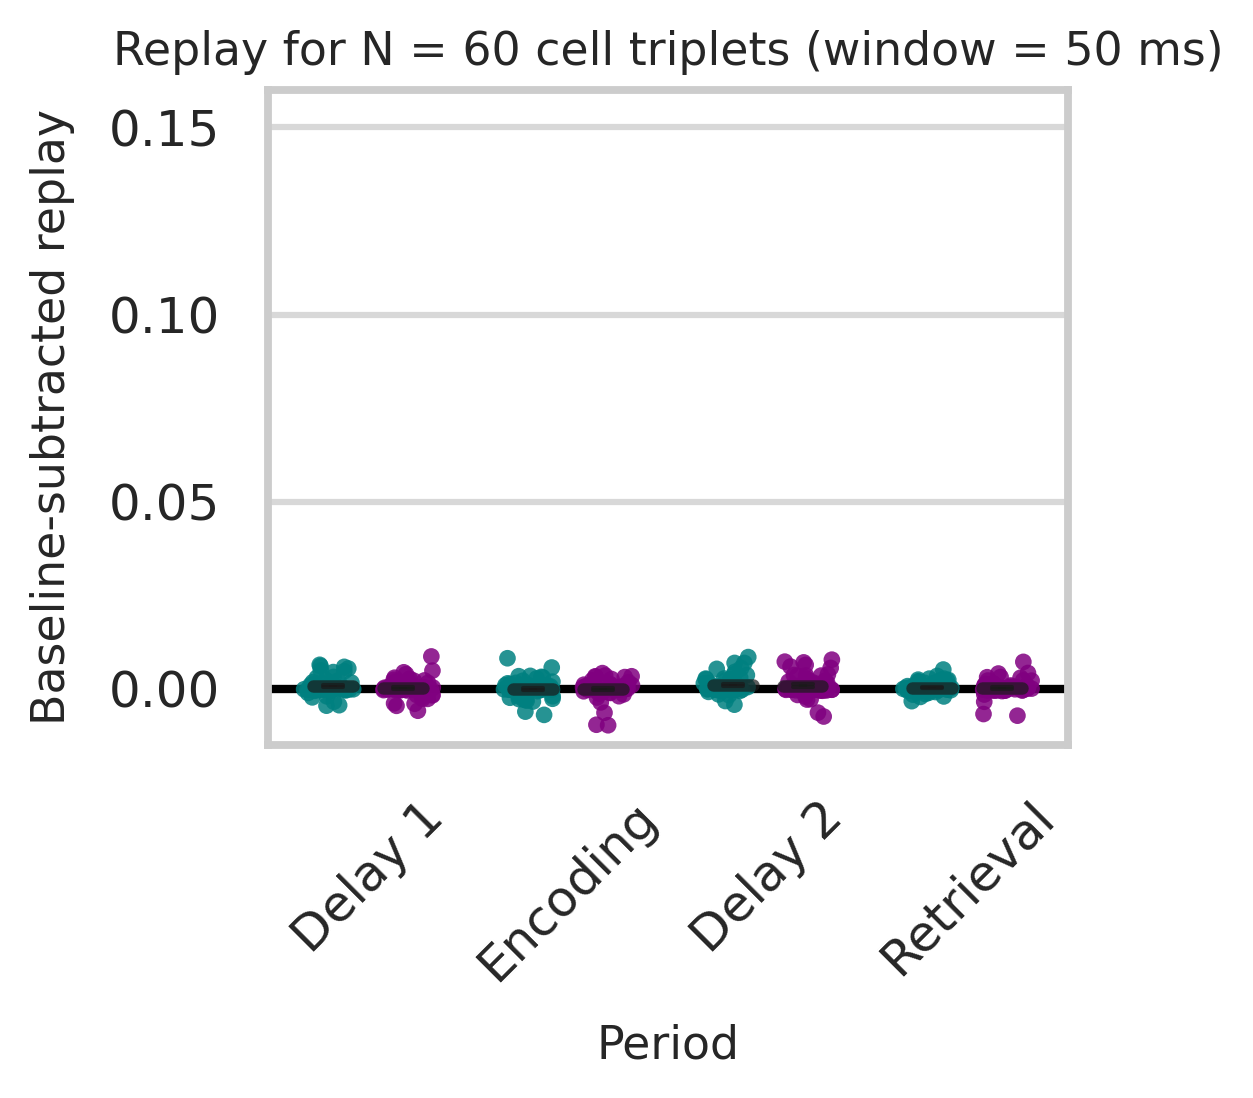

In [27]:
# Build tidy per-pair DataFrames for each period
df_delay2   = make_pair_swarm_df(real_d2t, perm_d2t, triple_index_df, period_label="Delay 2")
df_timeline = make_pair_swarm_df(real_tlt, perm_tlt, triple_index_df, period_label="Timeline")
df_delay1   = make_pair_swarm_df(real_d1t, perm_d1t, triple_index_df, period_label="Delay 1")
df_encode   = make_pair_swarm_df(real_enct,  perm_enct,  triple_index_df, period_label="Encoding")
df_retrieve = make_pair_swarm_df(real_rett,  perm_rett,  triple_index_df, period_label="Retrieval")

# Concatenate (each row = one pair × direction)
df_all = pd.concat([df_delay2, df_timeline, df_delay1,df_encode, df_retrieve], ignore_index=True)

# Optional: match the y-limits you used elsewhere
common_ylim = (-0.06, 0.16)

# Plot: x = period (3 groups), hue = direction; pooled across sessions
# df_delay2 / df_timeline / df_delay1 from make_pair_swarm_df(...)

plot_pair_swarm_by_period(
    df_all_periods=df_all,
    period_order=("Delay 1","Encoding", "Delay 2","Retrieval"),
    replay_flag=0, # 0=both, 1=forward only, 2=reverse only
    common_ylim=(-0.015, 0.16),
    title=f"Replay for N = {len(np.unique(df_all.triple_idx))} cell triplets (window = {replay_window} ms)",
    palette={"forward":"teal","reverse":"purple"},
    meanbar_halfwidth=0.1,
    bar_center_scale=7
)


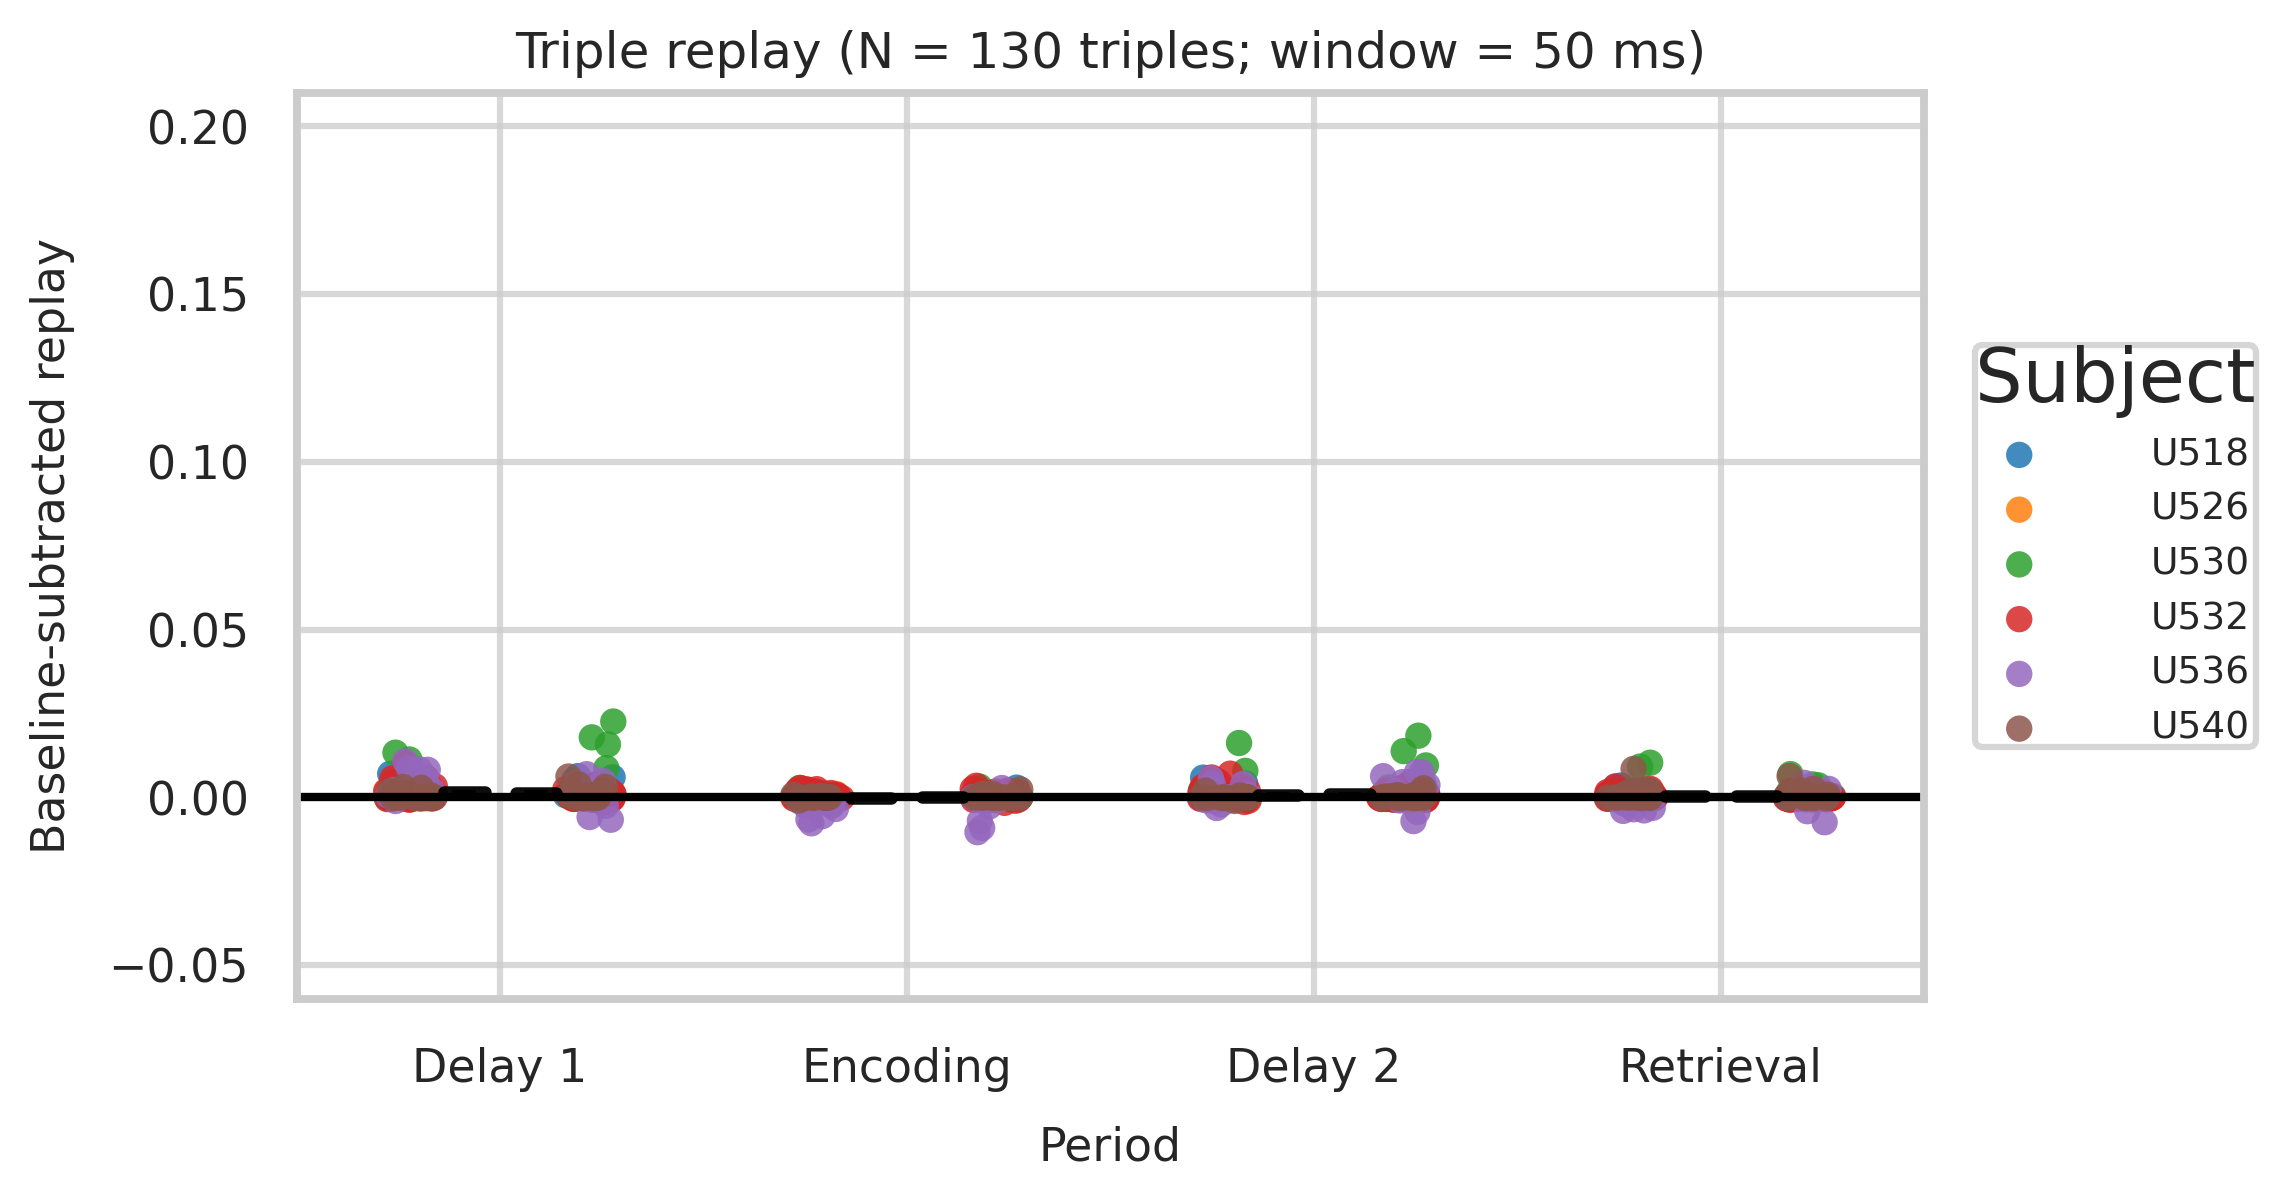

In [15]:
# Build tidy per-triple DataFrames for each period
df_delay2   = make_triple_swarm_df(real_d2t,   perm_d2t,   triple_index_df, period_label="Delay 2")
df_delay1   = make_triple_swarm_df(real_d1t,   perm_d1t,   triple_index_df, period_label="Delay 1")
df_encode   = make_triple_swarm_df(real_enct,  perm_enct,  triple_index_df, period_label="Encoding")
df_retrieve = make_triple_swarm_df(real_rett,  perm_rett,  triple_index_df, period_label="Retrieval")

df_all_triples = pd.concat([df_delay2, df_delay1, df_encode, df_retrieve], ignore_index=True)

# Reuse your existing plot (it only needs column 'n1' to color subjects)
plot_pair_swarm_by_period_with_sub_colors(
    df_all_periods=df_all_triples,
    period_order=("Delay 1","Encoding","Delay 2","Retrieval"),
    common_ylim=(-0.06, 0.21),
    title=f"Triple replay (N = {len(np.unique(df_all_triples.triple_idx))} triples; window = {replay_window} ms)",
    meanbar_halfwidth=0.05,
    bar_center_scale=0.4
)